<a href="https://colab.research.google.com/github/ednavivianasegura/Curso_ML_Python/blob/main/Modulo3_RedesNeuronales/redes_convolucionales_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Autores:** Edna Viviana Segura Alvarado - Hans Mauricio Carrillo Hernández

**Institución:** Universidad de la Rioja

**Fecha:** Junio/2025

**Clasificación de Imágenes con Redes Neuronales Convolucionales**

Las redes neuronales convolucionales son conocidas habitualmente por sus siglas en inglés, CNNs (Convolutional Neural Networks).


In [1]:
!git clone https://github.com/ednavivianasegura/Curso_ML_Python.git

fatal: destination path 'Curso_ML_Python' already exists and is not an empty directory.


In [2]:
# @title
import os
os.chdir("/content/Curso_ML_Python/Modulo3_RedesNeuronales")

In [3]:
# @title
# Celda 1: Instalar gdown y definir variables
!pip install gdown -q
FILE_ID       = '1JQ9OgAMs_AjgtuwI6vujqIkvxCtRX6av'
ZIP_PATH      = '/content/datos_curso.zip'           # Ruta donde se guardará el zip
EXTRACT_PATH  = '/content/datos_curso'               # Ruta donde se descomprimirán las imágenes

# Celda 2: Descargar y descomprimir
import gdown
import zipfile
import os

# 1. Descargar el archivo usando gdown
print(f"Descargando dataset desde Google Drive...")
gdown.download(id=FILE_ID, output=ZIP_PATH, quiet=False)

# 2. Descomprimir el archivo
if os.path.exists(ZIP_PATH):
    print(f"Descomprimiendo en {EXTRACT_PATH}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("¡Listo! Los datos están disponibles.")
else:
    print("Error: No se pudo descargar el archivo.")

Descargando dataset desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1JQ9OgAMs_AjgtuwI6vujqIkvxCtRX6av
From (redirected): https://drive.google.com/uc?id=1JQ9OgAMs_AjgtuwI6vujqIkvxCtRX6av&confirm=t&uuid=3a3e2f77-cc66-4a21-9b76-17b7d2b7b6ff
To: /content/datos_curso.zip
100%|██████████| 332M/332M [00:05<00:00, 58.5MB/s]


Descomprimiendo en /content/datos_curso...
¡Listo! Los datos están disponibles.



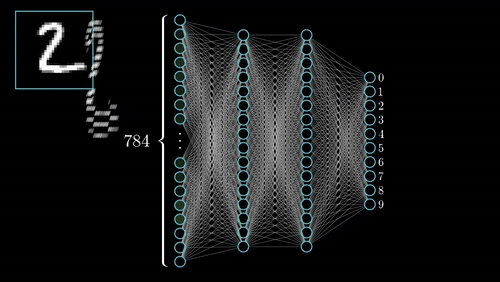
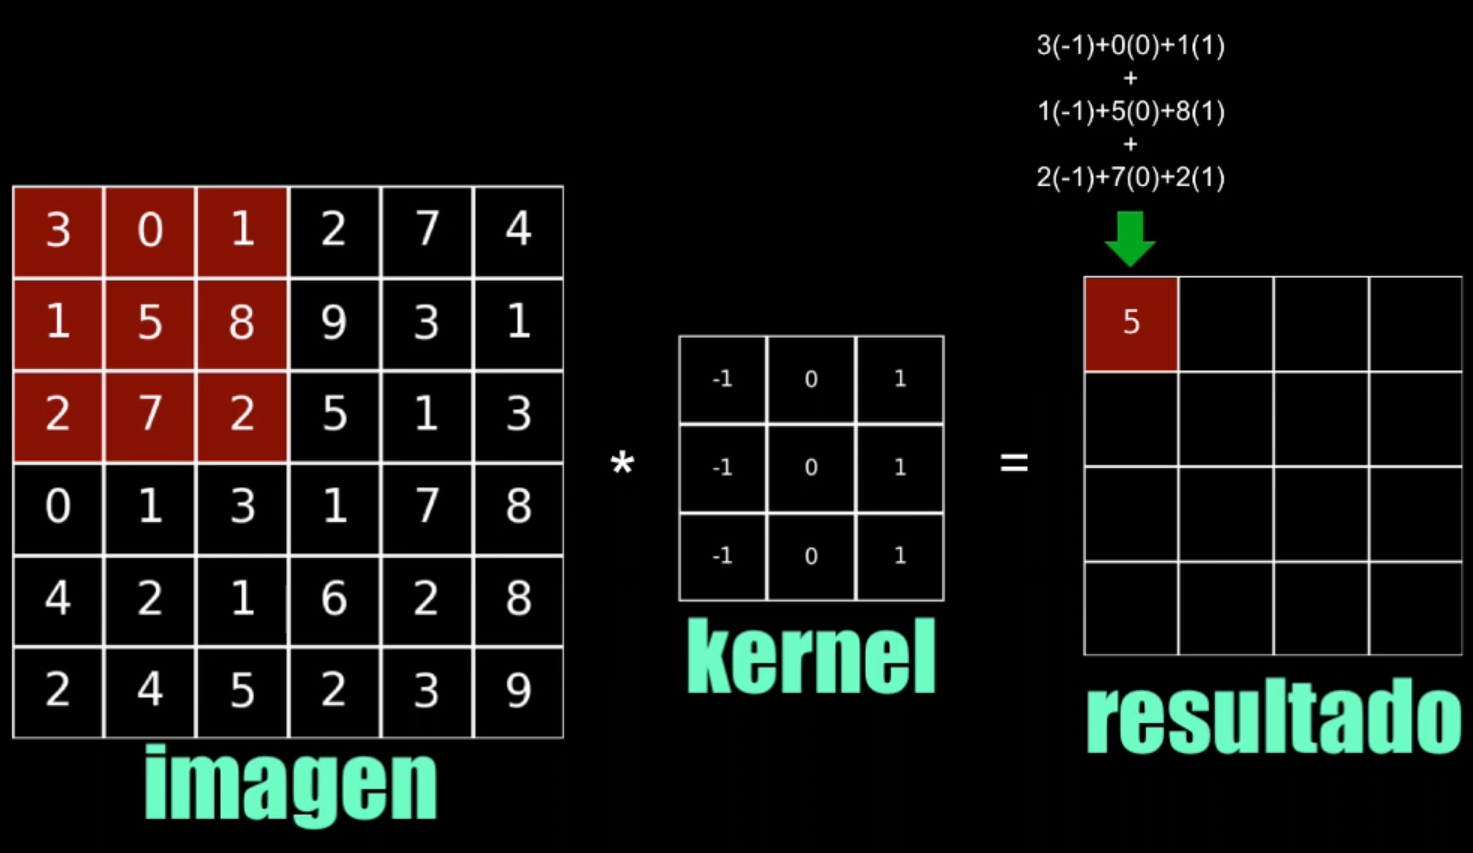

In [8]:
# @title
import base64
from IPython.display import HTML

# Lee y codifica el GIF en base64
with open("Imagenes/CNN_image_1.gif", "rb") as f:
    gif_b64 = base64.b64encode(f.read()).decode("utf-8")

with open("Imagenes/Conv1.png", "rb") as image_file_2:
    imagen = base64.b64encode(image_file_2.read()).decode()

gif_data_url = f"data:image/gif;base64,{gif_b64}"

html_content = f"""
<style>
  @import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Sans:ital,wght@0,300;0,400;0,600;0,700;1,400&family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Serif:wght@400;600&display=swap');
  .cnn-doc {{ font-family: 'IBM Plex Sans', sans-serif; font-size: 15px; line-height: 1.75; color: #1e293b; max-width: 860px; margin: 0 auto; padding: 10px 0 40px 0; background: transparent; }}
  .cnn-header {{ background: linear-gradient(135deg, #1E3A8A 0%, #1e40af 60%, #1d4ed8 100%); border-radius: 12px; padding: 36px 40px 32px; margin-bottom: 36px; position: relative; overflow: hidden; }}
  .cnn-header::before {{ content: ''; position: absolute; top: -40px; right: -40px; width: 200px; height: 200px; border-radius: 50%; background: rgba(255,255,255,0.05); }}
  .cnn-header::after {{ content: ''; position: absolute; bottom: -60px; left: 30%; width: 260px; height: 260px; border-radius: 50%; background: rgba(255,255,255,0.04); }}
  .cnn-header h1 {{ margin: 0 0 8px 0; font-size: 26px; font-weight: 700; color: #ffffff; letter-spacing: -0.3px; }}
  .cnn-header .subtitle {{ margin: 0; font-size: 14px; font-weight: 400; color: rgba(255,255,255,0.72); letter-spacing: 0.3px; }}
  .cnn-header .badge {{ display: inline-block; margin-top: 16px; background: rgba(255,255,255,0.15); color: #fff; font-size: 11px; font-weight: 600; letter-spacing: 1.2px; text-transform: uppercase; padding: 4px 12px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.25); }}
  .cnn-doc h2 {{ font-size: 19px; font-weight: 700; color: #1E3A8A; margin: 42px 0 6px 0; padding-bottom: 8px; border-bottom: 2px solid #dbeafe; display: flex; align-items: center; gap: 10px; }}
  .cnn-doc h2 .sec-num {{ display: inline-flex; align-items: center; justify-content: center; background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 700; width: 26px; height: 26px; border-radius: 6px; flex-shrink: 0; }}
  .cnn-doc h3 {{ font-size: 14px; font-weight: 600; color: #475569; margin: 22px 0 6px 0; text-transform: uppercase; letter-spacing: 0.8px; }}
  .cnn-doc p {{ margin: 0 0 12px 0; color: #334155; font-size: 15px; }}
  .cnn-note {{ color: #94A3B8; font-size: 13.5px; font-style: italic; margin: 6px 0 14px 0; }}
  .cnn-eq {{ font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 15px; font-weight: 600; background: #f0fdfb; border-left: 3px solid #0F766E; padding: 10px 16px; border-radius: 0 6px 6px 0; margin: 14px 0; display: block; }}
  .cnn-eq-block {{ background: #f0fdfb; border: 1px solid #99f6e4; border-left: 4px solid #0F766E; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 16px 0; }}
  .cnn-eq-block .eq-label {{ font-size: 11px; font-weight: 600; letter-spacing: 1px; text-transform: uppercase; color: #0F766E; margin-bottom: 6px; }}
  .cnn-eq-block .eq-formula {{ font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 16px; font-weight: 600; }}
  .cnn-eq-block .eq-desc {{ font-size: 13px; color: #64748b; margin-top: 6px; }}
  .cnn-card {{ background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }}
  .cnn-card-blue {{ background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }}
  .cnn-highlight {{ background: linear-gradient(135deg, #eff6ff, #dbeafe); border: 1px solid #93c5fd; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 14.5px; color: #1e40af; font-weight: 500; }}
  .cnn-doc ul {{ margin: 8px 0 14px 0; padding-left: 0; list-style: none; }}
  .cnn-doc ul li {{ position: relative; padding-left: 22px; margin-bottom: 7px; color: #334155; font-size: 15px; }}
  .cnn-doc ul li::before {{ content: '▸'; position: absolute; left: 0; color: #1E3A8A; font-size: 12px; top: 3px; }}
  .cnn-doc ul li strong {{ color: #1E3A8A; font-weight: 600; }}
  .cnn-highlight {{ background: linear-gradient(135deg, #eff6ff, #dbeafe); border: 1px solid #93c5fd; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 14.5px; color: #1e40af; font-weight: 500; }}
</style>

<div class="cnn-doc">
  <div class="cnn-header">
    <div class="badge">Módulo 4 · Deep Learning</div>
    <h1>Redes Neuronales Convolucionales (CNN)</h1>
    <p class="subtitle">Arquitectura, entrenamiento y aplicaciones en Visión Artificial con PyTorch</p>
  </div>

  <h2><span class="sec-num">1</span> Motivación: limitaciones de las redes densas en imágenes</h2>
  <p>
    Antes de las CNN, el enfoque estándar para clasificar imágenes consistía en "aplanar" todos los píxeles en un vector
    y alimentarlo a una red neuronal totalmente conectada (<em>Fully Connected Network</em> o FCN).
    Este método presenta problemas estructurales graves cuando se trabaja con imágenes reales.
  </p>

  <div style="text-align:center; margin: 24px 0;">
    <img src="{gif_data_url}"
         alt="CNN Animation"
         style="max-width: 100%;
                width: 520px;
                border-radius: 12px;
                box-shadow: 0 4px 14px rgba(0,0,0,0.12);">
  </div>

 <img
        src="data:image/png;base64,{imagen}"
        style="
            width:700px;
            border-radius:12px;
            box-shadow:0px 4px 12px rgba(0,0,0,0.25);
        "
    >



  <div class="cnn-eq-block">
    <div class="eq-label">Ejemplo · Imagen RGB 224×224</div>
    <div class="eq-formula">224 × 224 × 3 = 150 528 entradas por imagen</div>
    <div class="eq-desc">Una primera capa oculta de 1 024 neuronas requeriría <strong>~154 millones de parámetros</strong> solo en esa capa.</div>
  </div>
  <p>Esta explosión paramétrica genera cuatro problemas críticos:</p>
  <ul>
    <li><strong>Costo computacional:</strong> el número de multiplicaciones por propagación hace el entrenamiento prohibitivamente lento sin hardware especializado.</li>
    <li><strong>Sobreparametrización:</strong> modelos con más parámetros que ejemplos de entrenamiento tienden a memorizar, no a generalizar.</li>
    <li><strong>Pérdida de estructura espacial:</strong> al aplanar la imagen se pierde la información de vecindad, esencial en visión (un píxel es más relevante con sus vecinos inmediatos que con los lejanos).</li>
    <li><strong>No invarianza a traslaciones:</strong> si el objeto se desplaza levemente en la imagen, la red lo trata como una entrada completamente distinta.</li>
  </ul>
  <div class="cnn-highlight">
    💡 <strong>Idea clave:</strong> las imágenes tienen estructura local. Un detector de bordes útil en la esquina superior izquierda lo es también en el centro. Las CNN explotan este principio mediante parámetros compartidos.
  </div>
</div>
"""

display(HTML(html_content))

In [9]:
# @title
%%html
<style>

  .cnn-doc { font-family: 'IBM Plex Sans', sans-serif; font-size: 15px; line-height: 1.75; color: #1e293b; max-width: 860px; margin: 0 auto; padding: 10px 0 40px 0; background: transparent; }
  .cnn-header { background: linear-gradient(135deg, #1E3A8A 0%, #1e40af 60%, #1d4ed8 100%); border-radius: 12px; padding: 36px 40px 32px; margin-bottom: 36px; position: relative; overflow: hidden; }
  .cnn-header::before { content: ''; position: absolute; top: -40px; right: -40px; width: 200px; height: 200px; border-radius: 50%; background: rgba(255,255,255,0.05); }
  .cnn-header::after { content: ''; position: absolute; bottom: -60px; left: 30%; width: 260px; height: 260px; border-radius: 50%; background: rgba(255,255,255,0.04); }
  .cnn-header h1 { margin: 0 0 8px 0; font-size: 26px; font-weight: 700; color: #ffffff; letter-spacing: -0.3px; }
  .cnn-header .subtitle { margin: 0; font-size: 14px; font-weight: 400; color: rgba(255,255,255,0.72); letter-spacing: 0.3px; }
  .cnn-header .badge { display: inline-block; margin-top: 16px; background: rgba(255,255,255,0.15); color: #fff; font-size: 11px; font-weight: 600; letter-spacing: 1.2px; text-transform: uppercase; padding: 4px 12px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.25); }
  .cnn-doc h2 { font-size: 19px; font-weight: 700; color: #1E3A8A; margin: 42px 0 6px 0; padding-bottom: 8px; border-bottom: 2px solid #dbeafe; display: flex; align-items: center; gap: 10px; }
  .cnn-doc h2 .sec-num { display: inline-flex; align-items: center; justify-content: center; background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 700; width: 26px; height: 26px; border-radius: 6px; flex-shrink: 0; }
  .cnn-doc h3 { font-size: 14px; font-weight: 600; color: #475569; margin: 22px 0 6px 0; text-transform: uppercase; letter-spacing: 0.8px; }
  .cnn-doc p { margin: 0 0 12px 0; color: #334155; font-size: 15px; }
  .cnn-note { color: #94A3B8; font-size: 13.5px; font-style: italic; margin: 6px 0 14px 0; }
  .cnn-eq { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 15px; font-weight: 600; background: #f0fdfb; border-left: 3px solid #0F766E; padding: 10px 16px; border-radius: 0 6px 6px 0; margin: 14px 0; display: block; }
  .cnn-eq-block { background: #f0fdfb; border: 1px solid #99f6e4; border-left: 4px solid #0F766E; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 16px 0; }
  .cnn-eq-block .eq-label { font-size: 11px; font-weight: 600; letter-spacing: 1px; text-transform: uppercase; color: #0F766E; margin-bottom: 6px; }
  .cnn-eq-block .eq-formula { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 16px; font-weight: 600; }
  .cnn-eq-block .eq-desc { font-size: 13px; color: #64748b; margin-top: 6px; }
  .cnn-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-card-blue { background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-highlight { background: linear-gradient(135deg, #eff6ff, #dbeafe); border: 1px solid #93c5fd; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 14.5px; color: #1e40af; font-weight: 500; }
  .cnn-doc ul { margin: 8px 0 14px 0; padding-left: 0; list-style: none; }
  .cnn-doc ul li { position: relative; padding-left: 22px; margin-bottom: 7px; color: #334155; font-size: 15px; }
  .cnn-doc ul li::before { content: '▸'; position: absolute; left: 0; color: #1E3A8A; font-size: 12px; top: 3px; }
  .cnn-doc ul li strong { color: #1E3A8A; font-weight: 600; }
  .cnn-pipeline { display: flex; flex-direction: column; gap: 0; margin: 18px 0; max-width: 380px; }
  .pipeline-step { display: flex; align-items: center; gap: 14px; }
  .pipeline-block { display: flex; align-items: center; justify-content: space-between; background: #fff; border: 1.5px solid #bfdbfe; border-radius: 8px; padding: 10px 18px; flex: 1; transition: background 0.15s; }
  .pipeline-block:hover { background: #eff6ff; }
  .pipeline-block .pb-name { font-weight: 600; color: #1E3A8A; font-size: 14px; }
  .pipeline-block .pb-desc { font-size: 12px; color: #94A3B8; }
  .pipeline-arrow { width: 24px; text-align: center; color: #93c5fd; font-size: 18px; line-height: 1; padding: 4px 0; margin-left: 12px; flex-shrink: 0; }
  .pipeline-step:last-child .pipeline-arrow { display: none; }
  .kernel-grid { display: inline-grid; grid-template-columns: repeat(3, 42px); gap: 3px; margin: 12px 0 4px 0; }
  .kernel-cell { width: 42px; height: 42px; display: flex; align-items: center; justify-content: center; font-family: 'IBM Plex Mono', monospace; font-size: 14px; font-weight: 600; border-radius: 5px; }
  .kc-neg { background: #fee2e2; color: #b91c1c; }
  .kc-zero { background: #f1f5f9; color: #94a3b8; }
  .kc-pos { background: #dcfce7; color: #15803d; }
  .cnn-cols { display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 14px 0; }
  .cnn-col-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 16px 18px; }
  .cnn-col-card h4 { font-size: 13px; font-weight: 700; color: #1E3A8A; margin: 0 0 8px 0; text-transform: uppercase; letter-spacing: 0.5px; }
  .cnn-tags { display: flex; flex-wrap: wrap; gap: 8px; margin: 12px 0; }
  .cnn-tag { background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; letter-spacing: 0.3px; }
  .cnn-tag-teal { background: #0F766E; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-tag-gray { background: #e2e8f0; color: #475569; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-divider { border: none; border-top: 1px solid #e2e8f0; margin: 8px 0; }
  .cnn-table { width: 100%; border-collapse: collapse; margin: 14px 0; font-size: 14px; }
  .cnn-table th { background: #1E3A8A; color: #fff; padding: 9px 14px; text-align: left; font-weight: 600; font-size: 13px; letter-spacing: 0.4px; }
  .cnn-table th:first-child { border-radius: 8px 0 0 0; }
  .cnn-table th:last-child { border-radius: 0 8px 0 0; }
  .cnn-table td { padding: 9px 14px; border-bottom: 1px solid #e2e8f0; color: #334155; vertical-align: top; }
  .cnn-table tr:nth-child(even) td { background: #f8fafc; }
  .cnn-table td:first-child { font-weight: 600; color: #1E3A8A; }
  .cnn-pros li::before { content: '✓'; color: #0F766E; font-weight: 700; }
  .cnn-warn { background: #fffbeb; border: 1px solid #fde68a; border-left: 4px solid #f59e0b; border-radius: 0 8px 8px 0; padding: 13px 18px; margin: 14px 0; font-size: 14px; color: #92400e; }
  .app-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; margin: 14px 0; }
  .app-card { background: #f8fafc; border: 1px solid #e2e8f0; border-top: 3px solid #1E3A8A; border-radius: 8px; padding: 14px 16px; font-size: 13.5px; }
  .app-card .app-icon { font-size: 20px; margin-bottom: 6px; }
  .app-card .app-title { font-weight: 700; color: #1E3A8A; font-size: 13px; margin-bottom: 4px; }
  .app-card .app-desc { color: #64748b; font-size: 12.5px; line-height: 1.5; }
</style>
<div class="cnn-doc">
  <h2><span class="sec-num">2</span> ¿Qué aprende una CNN?</h2>
  <p>
    Una CNN aprende una jerarquía de representaciones visuales de forma automática, sin que el programador defina
    manualmente qué características buscar. Este proceso sigue una progresión desde lo simple hacia lo abstracto:
  </p>
  <div class="cnn-cols">
    <div class="cnn-col-card"><h4>Capas tempranas</h4><ul><li>Bordes y gradientes de color</li><li>Frecuencias y texturas básicas</li><li>Contornos orientados</li></ul></div>
    <div class="cnn-col-card"><h4>Capas intermedias</h4><ul><li>Formas geométricas compuestas</li><li>Patrones de textura complejos</li><li>Partes de objetos</li></ul></div>
    <div class="cnn-col-card"><h4>Capas profundas</h4><ul><li>Regiones semánticas completas</li><li>Objetos reconocibles</li><li>Conceptos visuales abstractos</li></ul></div>
    <div class="cnn-col-card"><h4>Capa de clasificación</h4><ul><li>Combinación de evidencias</li><li>Decisión de clase final</li><li>Distribución de probabilidad</li></ul></div>
  </div>
  <p class="cnn-note">
    Este fenómeno de jerarquía fue descubierto en parte gracias a técnicas de visualización de activaciones
    (Zeiler &amp; Fergus, 2013), y guarda analogía con el sistema visual biológico (córtex V1–V5).
  </p>
</div>

In [10]:
# @title
%%html
<style>

  .cnn-doc { font-family: 'IBM Plex Sans', sans-serif; font-size: 15px; line-height: 1.75; color: #1e293b; max-width: 860px; margin: 0 auto; padding: 10px 0 40px 0; background: transparent; }
  .cnn-header { background: linear-gradient(135deg, #1E3A8A 0%, #1e40af 60%, #1d4ed8 100%); border-radius: 12px; padding: 36px 40px 32px; margin-bottom: 36px; position: relative; overflow: hidden; }
  .cnn-header::before { content: ''; position: absolute; top: -40px; right: -40px; width: 200px; height: 200px; border-radius: 50%; background: rgba(255,255,255,0.05); }
  .cnn-header::after { content: ''; position: absolute; bottom: -60px; left: 30%; width: 260px; height: 260px; border-radius: 50%; background: rgba(255,255,255,0.04); }
  .cnn-header h1 { margin: 0 0 8px 0; font-size: 26px; font-weight: 700; color: #ffffff; letter-spacing: -0.3px; }
  .cnn-header .subtitle { margin: 0; font-size: 14px; font-weight: 400; color: rgba(255,255,255,0.72); letter-spacing: 0.3px; }
  .cnn-header .badge { display: inline-block; margin-top: 16px; background: rgba(255,255,255,0.15); color: #fff; font-size: 11px; font-weight: 600; letter-spacing: 1.2px; text-transform: uppercase; padding: 4px 12px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.25); }
  .cnn-doc h2 { font-size: 19px; font-weight: 700; color: #1E3A8A; margin: 42px 0 6px 0; padding-bottom: 8px; border-bottom: 2px solid #dbeafe; display: flex; align-items: center; gap: 10px; }
  .cnn-doc h2 .sec-num { display: inline-flex; align-items: center; justify-content: center; background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 700; width: 26px; height: 26px; border-radius: 6px; flex-shrink: 0; }
  .cnn-doc h3 { font-size: 14px; font-weight: 600; color: #475569; margin: 22px 0 6px 0; text-transform: uppercase; letter-spacing: 0.8px; }
  .cnn-doc p { margin: 0 0 12px 0; color: #334155; font-size: 15px; }
  .cnn-note { color: #94A3B8; font-size: 13.5px; font-style: italic; margin: 6px 0 14px 0; }
  .cnn-eq { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 15px; font-weight: 600; background: #f0fdfb; border-left: 3px solid #0F766E; padding: 10px 16px; border-radius: 0 6px 6px 0; margin: 14px 0; display: block; }
  .cnn-eq-block { background: #f0fdfb; border: 1px solid #99f6e4; border-left: 4px solid #0F766E; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 16px 0; }
  .cnn-eq-block .eq-label { font-size: 11px; font-weight: 600; letter-spacing: 1px; text-transform: uppercase; color: #0F766E; margin-bottom: 6px; }
  .cnn-eq-block .eq-formula { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 16px; font-weight: 600; }
  .cnn-eq-block .eq-desc { font-size: 13px; color: #64748b; margin-top: 6px; }
  .cnn-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-card-blue { background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-highlight { background: linear-gradient(135deg, #eff6ff, #dbeafe); border: 1px solid #93c5fd; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 14.5px; color: #1e40af; font-weight: 500; }
  .cnn-doc ul { margin: 8px 0 14px 0; padding-left: 0; list-style: none; }
  .cnn-doc ul li { position: relative; padding-left: 22px; margin-bottom: 7px; color: #334155; font-size: 15px; }
  .cnn-doc ul li::before { content: '▸'; position: absolute; left: 0; color: #1E3A8A; font-size: 12px; top: 3px; }
  .cnn-doc ul li strong { color: #1E3A8A; font-weight: 600; }
  .cnn-pipeline { display: flex; flex-direction: column; gap: 0; margin: 18px 0; max-width: 380px; }
  .pipeline-step { display: flex; align-items: center; gap: 14px; }
  .pipeline-block { display: flex; align-items: center; justify-content: space-between; background: #fff; border: 1.5px solid #bfdbfe; border-radius: 8px; padding: 10px 18px; flex: 1; transition: background 0.15s; }
  .pipeline-block:hover { background: #eff6ff; }
  .pipeline-block .pb-name { font-weight: 600; color: #1E3A8A; font-size: 14px; }
  .pipeline-block .pb-desc { font-size: 12px; color: #94A3B8; }
  .pipeline-arrow { width: 24px; text-align: center; color: #93c5fd; font-size: 18px; line-height: 1; padding: 4px 0; margin-left: 12px; flex-shrink: 0; }
  .pipeline-step:last-child .pipeline-arrow { display: none; }
  .kernel-grid { display: inline-grid; grid-template-columns: repeat(3, 42px); gap: 3px; margin: 12px 0 4px 0; }
  .kernel-cell { width: 42px; height: 42px; display: flex; align-items: center; justify-content: center; font-family: 'IBM Plex Mono', monospace; font-size: 14px; font-weight: 600; border-radius: 5px; }
  .kc-neg { background: #fee2e2; color: #b91c1c; }
  .kc-zero { background: #f1f5f9; color: #94a3b8; }
  .kc-pos { background: #dcfce7; color: #15803d; }
  .cnn-cols { display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 14px 0; }
  .cnn-col-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 16px 18px; }
  .cnn-col-card h4 { font-size: 13px; font-weight: 700; color: #1E3A8A; margin: 0 0 8px 0; text-transform: uppercase; letter-spacing: 0.5px; }
  .cnn-tags { display: flex; flex-wrap: wrap; gap: 8px; margin: 12px 0; }
  .cnn-tag { background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; letter-spacing: 0.3px; }
  .cnn-tag-teal { background: #0F766E; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-tag-gray { background: #e2e8f0; color: #475569; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-divider { border: none; border-top: 1px solid #e2e8f0; margin: 8px 0; }
  .cnn-table { width: 100%; border-collapse: collapse; margin: 14px 0; font-size: 14px; }
  .cnn-table th { background: #1E3A8A; color: #fff; padding: 9px 14px; text-align: left; font-weight: 600; font-size: 13px; letter-spacing: 0.4px; }
  .cnn-table th:first-child { border-radius: 8px 0 0 0; }
  .cnn-table th:last-child { border-radius: 0 8px 0 0; }
  .cnn-table td { padding: 9px 14px; border-bottom: 1px solid #e2e8f0; color: #334155; vertical-align: top; }
  .cnn-table tr:nth-child(even) td { background: #f8fafc; }
  .cnn-table td:first-child { font-weight: 600; color: #1E3A8A; }
  .cnn-pros li::before { content: '✓'; color: #0F766E; font-weight: 700; }
  .cnn-warn { background: #fffbeb; border: 1px solid #fde68a; border-left: 4px solid #f59e0b; border-radius: 0 8px 8px 0; padding: 13px 18px; margin: 14px 0; font-size: 14px; color: #92400e; }
  .app-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; margin: 14px 0; }
  .app-card { background: #f8fafc; border: 1px solid #e2e8f0; border-top: 3px solid #1E3A8A; border-radius: 8px; padding: 14px 16px; font-size: 13.5px; }
  .app-card .app-icon { font-size: 20px; margin-bottom: 6px; }
  .app-card .app-title { font-weight: 700; color: #1E3A8A; font-size: 13px; margin-bottom: 4px; }
  .app-card .app-desc { color: #64748b; font-size: 12.5px; line-height: 1.5; }
</style>

<div class="cnn-doc">
  <h2><span class="sec-num">3</span> La operación de convolución</h2>
  <p>La convolución discreta 2D es la operación matemática central de toda CNN...</p>
  <div class="cnn-eq-block">
    <div class="eq-label">Definición · Convolución 2D</div>
    <div class="eq-formula">(I * K)[i, j] = Σₘ Σₙ I[i+m, j+n] · K[m, n]</div>
  </div>
  <h3>3.1 Kernels y Feature Maps</h3>
  <p>Cada kernel detecta un tipo específico de patrón...</p>
  <div class="kernel-grid">
    <div class="kernel-cell kc-neg">−1</div><div class="kernel-cell kc-zero">0</div><div class="kernel-cell kc-pos">+1</div>
    <div class="kernel-cell kc-neg">−1</div><div class="kernel-cell kc-zero">0</div><div class="kernel-cell kc-pos">+1</div>
    <div class="kernel-cell kc-neg">−1</div><div class="kernel-cell kc-zero">0</div><div class="kernel-cell kc-pos">+1</div>
  </div>
  <h3>3.2 Hiperparámetros de la convolución</h3>
  <table class="cnn-table"><thead><tr><th>Parámetro</th><th>Descripción</th><th>Efecto</th></tr></thead>
  <tbody><tr><td>Kernel size (k)</td><td>Tamaño del filtro</td><td>Reduce salida en (k-1)</td></tr>
  <tr><td>Stride (s)</td><td>Paso de desplazamiento</td><td>Salida ≈ ⌊(W−k)/s⌋+1</td></tr>
  <tr><td>Padding (p)</td><td>Bordes artificiales</td><td>Con p=(k-1)/2 preserva resolución</td></tr>
  <tr><td>Num. de filtros</td><td>Cantidad de kernels</td><td>Incrementa profundidad</td></tr></tbody></table>
  <div class="cnn-eq-block"><div class="eq-label">Fórmula · Dimensión de salida</div><div class="eq-formula">H_out = ⌊(H_in + 2p − k) / s⌋ + 1</div></div>
  <h3>3.3 Compartición de parámetros</h3>
  <div class="cnn-cols">
    <div class="cnn-col-card"><h4>Capa densa (FCN)</h4><ul><li>224×224×3 → 1024 neuronas</li><li>~154 M parámetros</li></ul></div>
    <div class="cnn-col-card"><h4>Capa convolucional</h4><ul><li>64 filtros 3×3</li><li><strong>1 792 parámetros</strong></li></ul></div>
  </div>
</div>



Parámetro,Descripción,Efecto
Kernel size (k),Tamaño del filtro,Reduce salida en (k-1)
Stride (s),Paso de desplazamiento,Salida ≈ ⌊(W−k)/s⌋+1
Padding (p),Bordes artificiales,Con p=(k-1)/2 preserva resolución
Num. de filtros,Cantidad de kernels,Incrementa profundidad


In [11]:
# @title
%%html
<style>

  .cnn-doc { font-family: 'IBM Plex Sans', sans-serif; font-size: 15px; line-height: 1.75; color: #1e293b; max-width: 860px; margin: 0 auto; padding: 10px 0 40px 0; background: transparent; }
  .cnn-header { background: linear-gradient(135deg, #1E3A8A 0%, #1e40af 60%, #1d4ed8 100%); border-radius: 12px; padding: 36px 40px 32px; margin-bottom: 36px; position: relative; overflow: hidden; }
  .cnn-header::before { content: ''; position: absolute; top: -40px; right: -40px; width: 200px; height: 200px; border-radius: 50%; background: rgba(255,255,255,0.05); }
  .cnn-header::after { content: ''; position: absolute; bottom: -60px; left: 30%; width: 260px; height: 260px; border-radius: 50%; background: rgba(255,255,255,0.04); }
  .cnn-header h1 { margin: 0 0 8px 0; font-size: 26px; font-weight: 700; color: #ffffff; letter-spacing: -0.3px; }
  .cnn-header .subtitle { margin: 0; font-size: 14px; font-weight: 400; color: rgba(255,255,255,0.72); letter-spacing: 0.3px; }
  .cnn-header .badge { display: inline-block; margin-top: 16px; background: rgba(255,255,255,0.15); color: #fff; font-size: 11px; font-weight: 600; letter-spacing: 1.2px; text-transform: uppercase; padding: 4px 12px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.25); }
  .cnn-doc h2 { font-size: 19px; font-weight: 700; color: #1E3A8A; margin: 42px 0 6px 0; padding-bottom: 8px; border-bottom: 2px solid #dbeafe; display: flex; align-items: center; gap: 10px; }
  .cnn-doc h2 .sec-num { display: inline-flex; align-items: center; justify-content: center; background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 700; width: 26px; height: 26px; border-radius: 6px; flex-shrink: 0; }
  .cnn-doc h3 { font-size: 14px; font-weight: 600; color: #475569; margin: 22px 0 6px 0; text-transform: uppercase; letter-spacing: 0.8px; }
  .cnn-doc p { margin: 0 0 12px 0; color: #334155; font-size: 15px; }
  .cnn-note { color: #94A3B8; font-size: 13.5px; font-style: italic; margin: 6px 0 14px 0; }
  .cnn-eq { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 15px; font-weight: 600; background: #f0fdfb; border-left: 3px solid #0F766E; padding: 10px 16px; border-radius: 0 6px 6px 0; margin: 14px 0; display: block; }
  .cnn-eq-block { background: #f0fdfb; border: 1px solid #99f6e4; border-left: 4px solid #0F766E; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 16px 0; }
  .cnn-eq-block .eq-label { font-size: 11px; font-weight: 600; letter-spacing: 1px; text-transform: uppercase; color: #0F766E; margin-bottom: 6px; }
  .cnn-eq-block .eq-formula { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 16px; font-weight: 600; }
  .cnn-eq-block .eq-desc { font-size: 13px; color: #64748b; margin-top: 6px; }
  .cnn-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-card-blue { background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-highlight { background: linear-gradient(135deg, #eff6ff, #dbeafe); border: 1px solid #93c5fd; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 14.5px; color: #1e40af; font-weight: 500; }
  .cnn-doc ul { margin: 8px 0 14px 0; padding-left: 0; list-style: none; }
  .cnn-doc ul li { position: relative; padding-left: 22px; margin-bottom: 7px; color: #334155; font-size: 15px; }
  .cnn-doc ul li::before { content: '▸'; position: absolute; left: 0; color: #1E3A8A; font-size: 12px; top: 3px; }
  .cnn-doc ul li strong { color: #1E3A8A; font-weight: 600; }
  .cnn-pipeline { display: flex; flex-direction: column; gap: 0; margin: 18px 0; max-width: 380px; }
  .pipeline-step { display: flex; align-items: center; gap: 14px; }
  .pipeline-block { display: flex; align-items: center; justify-content: space-between; background: #fff; border: 1.5px solid #bfdbfe; border-radius: 8px; padding: 10px 18px; flex: 1; transition: background 0.15s; }
  .pipeline-block:hover { background: #eff6ff; }
  .pipeline-block .pb-name { font-weight: 600; color: #1E3A8A; font-size: 14px; }
  .pipeline-block .pb-desc { font-size: 12px; color: #94A3B8; }
  .pipeline-arrow { width: 24px; text-align: center; color: #93c5fd; font-size: 18px; line-height: 1; padding: 4px 0; margin-left: 12px; flex-shrink: 0; }
  .pipeline-step:last-child .pipeline-arrow { display: none; }
  .kernel-grid { display: inline-grid; grid-template-columns: repeat(3, 42px); gap: 3px; margin: 12px 0 4px 0; }
  .kernel-cell { width: 42px; height: 42px; display: flex; align-items: center; justify-content: center; font-family: 'IBM Plex Mono', monospace; font-size: 14px; font-weight: 600; border-radius: 5px; }
  .kc-neg { background: #fee2e2; color: #b91c1c; }
  .kc-zero { background: #f1f5f9; color: #94a3b8; }
  .kc-pos { background: #dcfce7; color: #15803d; }
  .cnn-cols { display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 14px 0; }
  .cnn-col-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 16px 18px; }
  .cnn-col-card h4 { font-size: 13px; font-weight: 700; color: #1E3A8A; margin: 0 0 8px 0; text-transform: uppercase; letter-spacing: 0.5px; }
  .cnn-tags { display: flex; flex-wrap: wrap; gap: 8px; margin: 12px 0; }
  .cnn-tag { background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; letter-spacing: 0.3px; }
  .cnn-tag-teal { background: #0F766E; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-tag-gray { background: #e2e8f0; color: #475569; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-divider { border: none; border-top: 1px solid #e2e8f0; margin: 8px 0; }
  .cnn-table { width: 100%; border-collapse: collapse; margin: 14px 0; font-size: 14px; }
  .cnn-table th { background: #1E3A8A; color: #fff; padding: 9px 14px; text-align: left; font-weight: 600; font-size: 13px; letter-spacing: 0.4px; }
  .cnn-table th:first-child { border-radius: 8px 0 0 0; }
  .cnn-table th:last-child { border-radius: 0 8px 0 0; }
  .cnn-table td { padding: 9px 14px; border-bottom: 1px solid #e2e8f0; color: #334155; vertical-align: top; }
  .cnn-table tr:nth-child(even) td { background: #f8fafc; }
  .cnn-table td:first-child { font-weight: 600; color: #1E3A8A; }
  .cnn-pros li::before { content: '✓'; color: #0F766E; font-weight: 700; }
  .cnn-warn { background: #fffbeb; border: 1px solid #fde68a; border-left: 4px solid #f59e0b; border-radius: 0 8px 8px 0; padding: 13px 18px; margin: 14px 0; font-size: 14px; color: #92400e; }
  .app-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; margin: 14px 0; }
  .app-card { background: #f8fafc; border: 1px solid #e2e8f0; border-top: 3px solid #1E3A8A; border-radius: 8px; padding: 14px 16px; font-size: 13.5px; }
  .app-card .app-icon { font-size: 20px; margin-bottom: 6px; }
  .app-card .app-title { font-weight: 700; color: #1E3A8A; font-size: 13px; margin-bottom: 4px; }
  .app-card .app-desc { color: #64748b; font-size: 12.5px; line-height: 1.5; }
</style>

<div class="cnn-doc">
  <h2><span class="sec-num">4</span> Capas principales de una CNN</h2>
  <h3>4.1 Capa convolucional</h3>
  <code class="cnn-eq">torch.nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)</code>
  <h3>4.2 Función de activación ReLU</h3>
  <div class="cnn-eq-block"><div class="eq-label">Activación · ReLU</div><div class="eq-formula">f(x) = max(0, x)</div></div>
  <h3>4.3 Pooling</h3>
  <div class="cnn-cols">
    <div class="cnn-col-card"><h4>Max Pooling</h4><p>Selecciona el valor máximo dentro de cada región. Reduce resolución ÷2.</p></div>
    <div class="cnn-col-card"><h4>Average Pooling</h4><p>Calcula el promedio. Usado como Global Average Pooling (GAP).</p></div>
  </div>
  <code class="cnn-eq">torch.nn.MaxPool2d(kernel_size=2, stride=2)</code>
  <h3>4.4 Capa Fully Connected (FC)</h3>
  <code class="cnn-eq">torch.nn.Linear(in_features=512, out_features=num_classes)</code>
</div>






In [12]:
%%html
<style>

  .cnn-doc { font-family: 'IBM Plex Sans', sans-serif; font-size: 15px; line-height: 1.75; color: #1e293b; max-width: 860px; margin: 0 auto; padding: 10px 0 40px 0; background: transparent; }
  .cnn-header { background: linear-gradient(135deg, #1E3A8A 0%, #1e40af 60%, #1d4ed8 100%); border-radius: 12px; padding: 36px 40px 32px; margin-bottom: 36px; position: relative; overflow: hidden; }
  .cnn-header::before { content: ''; position: absolute; top: -40px; right: -40px; width: 200px; height: 200px; border-radius: 50%; background: rgba(255,255,255,0.05); }
  .cnn-header::after { content: ''; position: absolute; bottom: -60px; left: 30%; width: 260px; height: 260px; border-radius: 50%; background: rgba(255,255,255,0.04); }
  .cnn-header h1 { margin: 0 0 8px 0; font-size: 26px; font-weight: 700; color: #ffffff; letter-spacing: -0.3px; }
  .cnn-header .subtitle { margin: 0; font-size: 14px; font-weight: 400; color: rgba(255,255,255,0.72); letter-spacing: 0.3px; }
  .cnn-header .badge { display: inline-block; margin-top: 16px; background: rgba(255,255,255,0.15); color: #fff; font-size: 11px; font-weight: 600; letter-spacing: 1.2px; text-transform: uppercase; padding: 4px 12px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.25); }
  .cnn-doc h2 { font-size: 19px; font-weight: 700; color: #1E3A8A; margin: 42px 0 6px 0; padding-bottom: 8px; border-bottom: 2px solid #dbeafe; display: flex; align-items: center; gap: 10px; }
  .cnn-doc h2 .sec-num { display: inline-flex; align-items: center; justify-content: center; background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 700; width: 26px; height: 26px; border-radius: 6px; flex-shrink: 0; }
  .cnn-doc h3 { font-size: 14px; font-weight: 600; color: #475569; margin: 22px 0 6px 0; text-transform: uppercase; letter-spacing: 0.8px; }
  .cnn-doc p { margin: 0 0 12px 0; color: #334155; font-size: 15px; }
  .cnn-note { color: #94A3B8; font-size: 13.5px; font-style: italic; margin: 6px 0 14px 0; }
  .cnn-eq { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 15px; font-weight: 600; background: #f0fdfb; border-left: 3px solid #0F766E; padding: 10px 16px; border-radius: 0 6px 6px 0; margin: 14px 0; display: block; }
  .cnn-eq-block { background: #f0fdfb; border: 1px solid #99f6e4; border-left: 4px solid #0F766E; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 16px 0; }
  .cnn-eq-block .eq-label { font-size: 11px; font-weight: 600; letter-spacing: 1px; text-transform: uppercase; color: #0F766E; margin-bottom: 6px; }
  .cnn-eq-block .eq-formula { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 16px; font-weight: 600; }
  .cnn-eq-block .eq-desc { font-size: 13px; color: #64748b; margin-top: 6px; }
  .cnn-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-card-blue { background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-highlight { background: linear-gradient(135deg, #eff6ff, #dbeafe); border: 1px solid #93c5fd; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 14.5px; color: #1e40af; font-weight: 500; }
  .cnn-doc ul { margin: 8px 0 14px 0; padding-left: 0; list-style: none; }
  .cnn-doc ul li { position: relative; padding-left: 22px; margin-bottom: 7px; color: #334155; font-size: 15px; }
  .cnn-doc ul li::before { content: '▸'; position: absolute; left: 0; color: #1E3A8A; font-size: 12px; top: 3px; }
  .cnn-doc ul li strong { color: #1E3A8A; font-weight: 600; }
  .cnn-pipeline { display: flex; flex-direction: column; gap: 0; margin: 18px 0; max-width: 380px; }
  .pipeline-step { display: flex; align-items: center; gap: 14px; }
  .pipeline-block { display: flex; align-items: center; justify-content: space-between; background: #fff; border: 1.5px solid #bfdbfe; border-radius: 8px; padding: 10px 18px; flex: 1; transition: background 0.15s; }
  .pipeline-block:hover { background: #eff6ff; }
  .pipeline-block .pb-name { font-weight: 600; color: #1E3A8A; font-size: 14px; }
  .pipeline-block .pb-desc { font-size: 12px; color: #94A3B8; }
  .pipeline-arrow { width: 24px; text-align: center; color: #93c5fd; font-size: 18px; line-height: 1; padding: 4px 0; margin-left: 12px; flex-shrink: 0; }
  .pipeline-step:last-child .pipeline-arrow { display: none; }
  .kernel-grid { display: inline-grid; grid-template-columns: repeat(3, 42px); gap: 3px; margin: 12px 0 4px 0; }
  .kernel-cell { width: 42px; height: 42px; display: flex; align-items: center; justify-content: center; font-family: 'IBM Plex Mono', monospace; font-size: 14px; font-weight: 600; border-radius: 5px; }
  .kc-neg { background: #fee2e2; color: #b91c1c; }
  .kc-zero { background: #f1f5f9; color: #94a3b8; }
  .kc-pos { background: #dcfce7; color: #15803d; }
  .cnn-cols { display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 14px 0; }
  .cnn-col-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 16px 18px; }
  .cnn-col-card h4 { font-size: 13px; font-weight: 700; color: #1E3A8A; margin: 0 0 8px 0; text-transform: uppercase; letter-spacing: 0.5px; }
  .cnn-tags { display: flex; flex-wrap: wrap; gap: 8px; margin: 12px 0; }
  .cnn-tag { background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; letter-spacing: 0.3px; }
  .cnn-tag-teal { background: #0F766E; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-tag-gray { background: #e2e8f0; color: #475569; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-divider { border: none; border-top: 1px solid #e2e8f0; margin: 8px 0; }
  .cnn-table { width: 100%; border-collapse: collapse; margin: 14px 0; font-size: 14px; }
  .cnn-table th { background: #1E3A8A; color: #fff; padding: 9px 14px; text-align: left; font-weight: 600; font-size: 13px; letter-spacing: 0.4px; }
  .cnn-table th:first-child { border-radius: 8px 0 0 0; }
  .cnn-table th:last-child { border-radius: 0 8px 0 0; }
  .cnn-table td { padding: 9px 14px; border-bottom: 1px solid #e2e8f0; color: #334155; vertical-align: top; }
  .cnn-table tr:nth-child(even) td { background: #f8fafc; }
  .cnn-table td:first-child { font-weight: 600; color: #1E3A8A; }
  .cnn-pros li::before { content: '✓'; color: #0F766E; font-weight: 700; }
  .cnn-warn { background: #fffbeb; border: 1px solid #fde68a; border-left: 4px solid #f59e0b; border-radius: 0 8px 8px 0; padding: 13px 18px; margin: 14px 0; font-size: 14px; color: #92400e; }
  .app-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; margin: 14px 0; }
  .app-card { background: #f8fafc; border: 1px solid #e2e8f0; border-top: 3px solid #1E3A8A; border-radius: 8px; padding: 14px 16px; font-size: 13.5px; }
  .app-card .app-icon { font-size: 20px; margin-bottom: 6px; }
  .app-card .app-title { font-weight: 700; color: #1E3A8A; font-size: 13px; margin-bottom: 4px; }
  .app-card .app-desc { color: #64748b; font-size: 12.5px; line-height: 1.5; }
</style>

<div class="cnn-doc">
  <h2><span class="sec-num">5</span> Flujo completo de una CNN</h2>
  <div class="cnn-pipeline">
    <div class="pipeline-step"><div class="pipeline-block"><span class="pb-name">Imagen de entrada</span><span class="pb-desc">224×224×3</span></div><div class="pipeline-arrow">↓</div></div>
    <div class="pipeline-step"><div class="pipeline-block"><span class="pb-name">Conv2d + ReLU</span><span class="pb-desc">Extracción</span></div><div class="pipeline-arrow">↓</div></div>
    <div class="pipeline-step"><div class="pipeline-block"><span class="pb-name">MaxPooling</span><span class="pb-desc">Reducción ÷2</span></div><div class="pipeline-arrow">↓</div></div>
    <div class="pipeline-step"><div class="pipeline-block"><span class="pb-name">Conv2d + ReLU (×N)</span><span class="pb-desc">Más filtros</span></div><div class="pipeline-arrow">↓</div></div>
    <div class="pipeline-step"><div class="pipeline-block"><span class="pb-name">Flatten / Global Avg Pooling</span><span class="pb-desc">Tensor → vector</span></div><div class="pipeline-arrow">↓</div></div>
    <div class="pipeline-step"><div class="pipeline-block"><span class="pb-name">Fully Connected + Dropout</span><span class="pb-desc">Clasificador</span></div><div class="pipeline-arrow">↓</div></div>
    <div class="pipeline-step"><div class="pipeline-block"><span class="pb-name">Softmax → Predicción</span><span class="pb-desc">Probabilidades</span></div></div>
  </div>
  <div class="cnn-eq-block"><div class="eq-label">Softmax</div><div class="eq-formula">P(y=k|x)=exp(zₖ)/Σⱼexp(zⱼ)</div></div>
</div>





In [13]:
# @title
%%html
<style>

  .cnn-doc { font-family: 'IBM Plex Sans', sans-serif; font-size: 15px; line-height: 1.75; color: #1e293b; max-width: 860px; margin: 0 auto; padding: 10px 0 40px 0; background: transparent; }
  .cnn-header { background: linear-gradient(135deg, #1E3A8A 0%, #1e40af 60%, #1d4ed8 100%); border-radius: 12px; padding: 36px 40px 32px; margin-bottom: 36px; position: relative; overflow: hidden; }
  .cnn-header::before { content: ''; position: absolute; top: -40px; right: -40px; width: 200px; height: 200px; border-radius: 50%; background: rgba(255,255,255,0.05); }
  .cnn-header::after { content: ''; position: absolute; bottom: -60px; left: 30%; width: 260px; height: 260px; border-radius: 50%; background: rgba(255,255,255,0.04); }
  .cnn-header h1 { margin: 0 0 8px 0; font-size: 26px; font-weight: 700; color: #ffffff; letter-spacing: -0.3px; }
  .cnn-header .subtitle { margin: 0; font-size: 14px; font-weight: 400; color: rgba(255,255,255,0.72); letter-spacing: 0.3px; }
  .cnn-header .badge { display: inline-block; margin-top: 16px; background: rgba(255,255,255,0.15); color: #fff; font-size: 11px; font-weight: 600; letter-spacing: 1.2px; text-transform: uppercase; padding: 4px 12px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.25); }
  .cnn-doc h2 { font-size: 19px; font-weight: 700; color: #1E3A8A; margin: 42px 0 6px 0; padding-bottom: 8px; border-bottom: 2px solid #dbeafe; display: flex; align-items: center; gap: 10px; }
  .cnn-doc h2 .sec-num { display: inline-flex; align-items: center; justify-content: center; background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 700; width: 26px; height: 26px; border-radius: 6px; flex-shrink: 0; }
  .cnn-doc h3 { font-size: 14px; font-weight: 600; color: #475569; margin: 22px 0 6px 0; text-transform: uppercase; letter-spacing: 0.8px; }
  .cnn-doc p { margin: 0 0 12px 0; color: #334155; font-size: 15px; }
  .cnn-note { color: #94A3B8; font-size: 13.5px; font-style: italic; margin: 6px 0 14px 0; }
  .cnn-eq { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 15px; font-weight: 600; background: #f0fdfb; border-left: 3px solid #0F766E; padding: 10px 16px; border-radius: 0 6px 6px 0; margin: 14px 0; display: block; }
  .cnn-eq-block { background: #f0fdfb; border: 1px solid #99f6e4; border-left: 4px solid #0F766E; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 16px 0; }
  .cnn-eq-block .eq-label { font-size: 11px; font-weight: 600; letter-spacing: 1px; text-transform: uppercase; color: #0F766E; margin-bottom: 6px; }
  .cnn-eq-block .eq-formula { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 16px; font-weight: 600; }
  .cnn-eq-block .eq-desc { font-size: 13px; color: #64748b; margin-top: 6px; }
  .cnn-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-card-blue { background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-highlight { background: linear-gradient(135deg, #eff6ff, #dbeafe); border: 1px solid #93c5fd; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 14.5px; color: #1e40af; font-weight: 500; }
  .cnn-doc ul { margin: 8px 0 14px 0; padding-left: 0; list-style: none; }
  .cnn-doc ul li { position: relative; padding-left: 22px; margin-bottom: 7px; color: #334155; font-size: 15px; }
  .cnn-doc ul li::before { content: '▸'; position: absolute; left: 0; color: #1E3A8A; font-size: 12px; top: 3px; }
  .cnn-doc ul li strong { color: #1E3A8A; font-weight: 600; }
  .cnn-pipeline { display: flex; flex-direction: column; gap: 0; margin: 18px 0; max-width: 380px; }
  .pipeline-step { display: flex; align-items: center; gap: 14px; }
  .pipeline-block { display: flex; align-items: center; justify-content: space-between; background: #fff; border: 1.5px solid #bfdbfe; border-radius: 8px; padding: 10px 18px; flex: 1; transition: background 0.15s; }
  .pipeline-block:hover { background: #eff6ff; }
  .pipeline-block .pb-name { font-weight: 600; color: #1E3A8A; font-size: 14px; }
  .pipeline-block .pb-desc { font-size: 12px; color: #94A3B8; }
  .pipeline-arrow { width: 24px; text-align: center; color: #93c5fd; font-size: 18px; line-height: 1; padding: 4px 0; margin-left: 12px; flex-shrink: 0; }
  .pipeline-step:last-child .pipeline-arrow { display: none; }
  .kernel-grid { display: inline-grid; grid-template-columns: repeat(3, 42px); gap: 3px; margin: 12px 0 4px 0; }
  .kernel-cell { width: 42px; height: 42px; display: flex; align-items: center; justify-content: center; font-family: 'IBM Plex Mono', monospace; font-size: 14px; font-weight: 600; border-radius: 5px; }
  .kc-neg { background: #fee2e2; color: #b91c1c; }
  .kc-zero { background: #f1f5f9; color: #94a3b8; }
  .kc-pos { background: #dcfce7; color: #15803d; }
  .cnn-cols { display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 14px 0; }
  .cnn-col-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 16px 18px; }
  .cnn-col-card h4 { font-size: 13px; font-weight: 700; color: #1E3A8A; margin: 0 0 8px 0; text-transform: uppercase; letter-spacing: 0.5px; }
  .cnn-tags { display: flex; flex-wrap: wrap; gap: 8px; margin: 12px 0; }
  .cnn-tag { background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; letter-spacing: 0.3px; }
  .cnn-tag-teal { background: #0F766E; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-tag-gray { background: #e2e8f0; color: #475569; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-divider { border: none; border-top: 1px solid #e2e8f0; margin: 8px 0; }
  .cnn-table { width: 100%; border-collapse: collapse; margin: 14px 0; font-size: 14px; }
  .cnn-table th { background: #1E3A8A; color: #fff; padding: 9px 14px; text-align: left; font-weight: 600; font-size: 13px; letter-spacing: 0.4px; }
  .cnn-table th:first-child { border-radius: 8px 0 0 0; }
  .cnn-table th:last-child { border-radius: 0 8px 0 0; }
  .cnn-table td { padding: 9px 14px; border-bottom: 1px solid #e2e8f0; color: #334155; vertical-align: top; }
  .cnn-table tr:nth-child(even) td { background: #f8fafc; }
  .cnn-table td:first-child { font-weight: 600; color: #1E3A8A; }
  .cnn-pros li::before { content: '✓'; color: #0F766E; font-weight: 700; }
  .cnn-warn { background: #fffbeb; border: 1px solid #fde68a; border-left: 4px solid #f59e0b; border-radius: 0 8px 8px 0; padding: 13px 18px; margin: 14px 0; font-size: 14px; color: #92400e; }
  .app-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; margin: 14px 0; }
  .app-card { background: #f8fafc; border: 1px solid #e2e8f0; border-top: 3px solid #1E3A8A; border-radius: 8px; padding: 14px 16px; font-size: 13.5px; }
  .app-card .app-icon { font-size: 20px; margin-bottom: 6px; }
  .app-card .app-title { font-weight: 700; color: #1E3A8A; font-size: 13px; margin-bottom: 4px; }
  .app-card .app-desc { color: #64748b; font-size: 12.5px; line-height: 1.5; }
</style>

<div class="cnn-doc">
  <h2><span class="sec-num">6</span> Entrenamiento: ciclo de aprendizaje</h2>
  <h3>6.1 Forward Pass</h3>
  <h3>6.2 Función de pérdida</h3>
  <div class="cnn-eq-block"><div class="eq-label">Loss · Cross-Entropy</div><div class="eq-formula">L = − Σₖ yₖ · log(ŷₖ)</div></div>
  <h3>6.3 Backpropagation</h3>
  <code class="cnn-eq">loss.backward()</code>
  <h3>6.4 Optimizadores</h3>
  <table class="cnn-table"><thead><tr><th>Optimizador</th><th>Cuándo usarlo</th></tr></thead>
  <tbody><tr><td>SGD + Momentum</td><td>Entrenamiento desde cero</td></tr>
  <tr><td>Adam</td><td>Fine‑tuning, prototipado rápido</td></tr>
  <tr><td>AdamW</td><td>Estándar actual en visión</td></tr></tbody></table>
</div>





Optimizador,Cuándo usarlo
SGD + Momentum,Entrenamiento desde cero
Adam,"Fine‑tuning, prototipado rápido"
AdamW,Estándar actual en visión


In [14]:
# @title
%%html
<style>

  .cnn-doc { font-family: 'IBM Plex Sans', sans-serif; font-size: 15px; line-height: 1.75; color: #1e293b; max-width: 860px; margin: 0 auto; padding: 10px 0 40px 0; background: transparent; }
  .cnn-header { background: linear-gradient(135deg, #1E3A8A 0%, #1e40af 60%, #1d4ed8 100%); border-radius: 12px; padding: 36px 40px 32px; margin-bottom: 36px; position: relative; overflow: hidden; }
  .cnn-header::before { content: ''; position: absolute; top: -40px; right: -40px; width: 200px; height: 200px; border-radius: 50%; background: rgba(255,255,255,0.05); }
  .cnn-header::after { content: ''; position: absolute; bottom: -60px; left: 30%; width: 260px; height: 260px; border-radius: 50%; background: rgba(255,255,255,0.04); }
  .cnn-header h1 { margin: 0 0 8px 0; font-size: 26px; font-weight: 700; color: #ffffff; letter-spacing: -0.3px; }
  .cnn-header .subtitle { margin: 0; font-size: 14px; font-weight: 400; color: rgba(255,255,255,0.72); letter-spacing: 0.3px; }
  .cnn-header .badge { display: inline-block; margin-top: 16px; background: rgba(255,255,255,0.15); color: #fff; font-size: 11px; font-weight: 600; letter-spacing: 1.2px; text-transform: uppercase; padding: 4px 12px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.25); }
  .cnn-doc h2 { font-size: 19px; font-weight: 700; color: #1E3A8A; margin: 42px 0 6px 0; padding-bottom: 8px; border-bottom: 2px solid #dbeafe; display: flex; align-items: center; gap: 10px; }
  .cnn-doc h2 .sec-num { display: inline-flex; align-items: center; justify-content: center; background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 700; width: 26px; height: 26px; border-radius: 6px; flex-shrink: 0; }
  .cnn-doc h3 { font-size: 14px; font-weight: 600; color: #475569; margin: 22px 0 6px 0; text-transform: uppercase; letter-spacing: 0.8px; }
  .cnn-doc p { margin: 0 0 12px 0; color: #334155; font-size: 15px; }
  .cnn-note { color: #94A3B8; font-size: 13.5px; font-style: italic; margin: 6px 0 14px 0; }
  .cnn-eq { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 15px; font-weight: 600; background: #f0fdfb; border-left: 3px solid #0F766E; padding: 10px 16px; border-radius: 0 6px 6px 0; margin: 14px 0; display: block; }
  .cnn-eq-block { background: #f0fdfb; border: 1px solid #99f6e4; border-left: 4px solid #0F766E; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 16px 0; }
  .cnn-eq-block .eq-label { font-size: 11px; font-weight: 600; letter-spacing: 1px; text-transform: uppercase; color: #0F766E; margin-bottom: 6px; }
  .cnn-eq-block .eq-formula { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 16px; font-weight: 600; }
  .cnn-eq-block .eq-desc { font-size: 13px; color: #64748b; margin-top: 6px; }
  .cnn-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-card-blue { background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-highlight { background: linear-gradient(135deg, #eff6ff, #dbeafe); border: 1px solid #93c5fd; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 14.5px; color: #1e40af; font-weight: 500; }
  .cnn-doc ul { margin: 8px 0 14px 0; padding-left: 0; list-style: none; }
  .cnn-doc ul li { position: relative; padding-left: 22px; margin-bottom: 7px; color: #334155; font-size: 15px; }
  .cnn-doc ul li::before { content: '▸'; position: absolute; left: 0; color: #1E3A8A; font-size: 12px; top: 3px; }
  .cnn-doc ul li strong { color: #1E3A8A; font-weight: 600; }
  .cnn-pipeline { display: flex; flex-direction: column; gap: 0; margin: 18px 0; max-width: 380px; }
  .pipeline-step { display: flex; align-items: center; gap: 14px; }
  .pipeline-block { display: flex; align-items: center; justify-content: space-between; background: #fff; border: 1.5px solid #bfdbfe; border-radius: 8px; padding: 10px 18px; flex: 1; transition: background 0.15s; }
  .pipeline-block:hover { background: #eff6ff; }
  .pipeline-block .pb-name { font-weight: 600; color: #1E3A8A; font-size: 14px; }
  .pipeline-block .pb-desc { font-size: 12px; color: #94A3B8; }
  .pipeline-arrow { width: 24px; text-align: center; color: #93c5fd; font-size: 18px; line-height: 1; padding: 4px 0; margin-left: 12px; flex-shrink: 0; }
  .pipeline-step:last-child .pipeline-arrow { display: none; }
  .kernel-grid { display: inline-grid; grid-template-columns: repeat(3, 42px); gap: 3px; margin: 12px 0 4px 0; }
  .kernel-cell { width: 42px; height: 42px; display: flex; align-items: center; justify-content: center; font-family: 'IBM Plex Mono', monospace; font-size: 14px; font-weight: 600; border-radius: 5px; }
  .kc-neg { background: #fee2e2; color: #b91c1c; }
  .kc-zero { background: #f1f5f9; color: #94a3b8; }
  .kc-pos { background: #dcfce7; color: #15803d; }
  .cnn-cols { display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 14px 0; }
  .cnn-col-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 16px 18px; }
  .cnn-col-card h4 { font-size: 13px; font-weight: 700; color: #1E3A8A; margin: 0 0 8px 0; text-transform: uppercase; letter-spacing: 0.5px; }
  .cnn-tags { display: flex; flex-wrap: wrap; gap: 8px; margin: 12px 0; }
  .cnn-tag { background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; letter-spacing: 0.3px; }
  .cnn-tag-teal { background: #0F766E; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-tag-gray { background: #e2e8f0; color: #475569; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-divider { border: none; border-top: 1px solid #e2e8f0; margin: 8px 0; }
  .cnn-table { width: 100%; border-collapse: collapse; margin: 14px 0; font-size: 14px; }
  .cnn-table th { background: #1E3A8A; color: #fff; padding: 9px 14px; text-align: left; font-weight: 600; font-size: 13px; letter-spacing: 0.4px; }
  .cnn-table th:first-child { border-radius: 8px 0 0 0; }
  .cnn-table th:last-child { border-radius: 0 8px 0 0; }
  .cnn-table td { padding: 9px 14px; border-bottom: 1px solid #e2e8f0; color: #334155; vertical-align: top; }
  .cnn-table tr:nth-child(even) td { background: #f8fafc; }
  .cnn-table td:first-child { font-weight: 600; color: #1E3A8A; }
  .cnn-pros li::before { content: '✓'; color: #0F766E; font-weight: 700; }
  .cnn-warn { background: #fffbeb; border: 1px solid #fde68a; border-left: 4px solid #f59e0b; border-radius: 0 8px 8px 0; padding: 13px 18px; margin: 14px 0; font-size: 14px; color: #92400e; }
  .app-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; margin: 14px 0; }
  .app-card { background: #f8fafc; border: 1px solid #e2e8f0; border-top: 3px solid #1E3A8A; border-radius: 8px; padding: 14px 16px; font-size: 13.5px; }
  .app-card .app-icon { font-size: 20px; margin-bottom: 6px; }
  .app-card .app-title { font-weight: 700; color: #1E3A8A; font-size: 13px; margin-bottom: 4px; }
  .app-card .app-desc { color: #64748b; font-size: 12.5px; line-height: 1.5; }
</style>

<div class="cnn-doc">
  <h2><span class="sec-num">7</span> Sobreajuste (Overfitting)</h2>
  <div class="cnn-warn">⚠️ Síntoma típico: accuracy en entrenamiento 95‑99% pero solo 60‑70% en validación.</div>
  <h3>Estrategias de regularización</h3>
  <div class="cnn-cols">
    <div class="cnn-col-card"><h4>Dropout</h4><code>nn.Dropout(p=0.5)</code></div>
    <div class="cnn-col-card"><h4>Batch Normalization</h4><p>Normaliza activaciones por mini‑batch</p></div>
    <div class="cnn-col-card"><h4>Weight Decay (L2)</h4><p>Añade λ‖w‖² a la pérdida</p></div>
    <div class="cnn-col-card"><h4>Early Stopping</h4><p>Detiene cuando validación deja de mejorar</p></div>
  </div>
</div>




In [15]:
# @title
%%html
<style>

  .cnn-doc { font-family: 'IBM Plex Sans', sans-serif; font-size: 15px; line-height: 1.75; color: #1e293b; max-width: 860px; margin: 0 auto; padding: 10px 0 40px 0; background: transparent; }
  .cnn-header { background: linear-gradient(135deg, #1E3A8A 0%, #1e40af 60%, #1d4ed8 100%); border-radius: 12px; padding: 36px 40px 32px; margin-bottom: 36px; position: relative; overflow: hidden; }
  .cnn-header::before { content: ''; position: absolute; top: -40px; right: -40px; width: 200px; height: 200px; border-radius: 50%; background: rgba(255,255,255,0.05); }
  .cnn-header::after { content: ''; position: absolute; bottom: -60px; left: 30%; width: 260px; height: 260px; border-radius: 50%; background: rgba(255,255,255,0.04); }
  .cnn-header h1 { margin: 0 0 8px 0; font-size: 26px; font-weight: 700; color: #ffffff; letter-spacing: -0.3px; }
  .cnn-header .subtitle { margin: 0; font-size: 14px; font-weight: 400; color: rgba(255,255,255,0.72); letter-spacing: 0.3px; }
  .cnn-header .badge { display: inline-block; margin-top: 16px; background: rgba(255,255,255,0.15); color: #fff; font-size: 11px; font-weight: 600; letter-spacing: 1.2px; text-transform: uppercase; padding: 4px 12px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.25); }
  .cnn-doc h2 { font-size: 19px; font-weight: 700; color: #1E3A8A; margin: 42px 0 6px 0; padding-bottom: 8px; border-bottom: 2px solid #dbeafe; display: flex; align-items: center; gap: 10px; }
  .cnn-doc h2 .sec-num { display: inline-flex; align-items: center; justify-content: center; background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 700; width: 26px; height: 26px; border-radius: 6px; flex-shrink: 0; }
  .cnn-doc h3 { font-size: 14px; font-weight: 600; color: #475569; margin: 22px 0 6px 0; text-transform: uppercase; letter-spacing: 0.8px; }
  .cnn-doc p { margin: 0 0 12px 0; color: #334155; font-size: 15px; }
  .cnn-note { color: #94A3B8; font-size: 13.5px; font-style: italic; margin: 6px 0 14px 0; }
  .cnn-eq { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 15px; font-weight: 600; background: #f0fdfb; border-left: 3px solid #0F766E; padding: 10px 16px; border-radius: 0 6px 6px 0; margin: 14px 0; display: block; }
  .cnn-eq-block { background: #f0fdfb; border: 1px solid #99f6e4; border-left: 4px solid #0F766E; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 16px 0; }
  .cnn-eq-block .eq-label { font-size: 11px; font-weight: 600; letter-spacing: 1px; text-transform: uppercase; color: #0F766E; margin-bottom: 6px; }
  .cnn-eq-block .eq-formula { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 16px; font-weight: 600; }
  .cnn-eq-block .eq-desc { font-size: 13px; color: #64748b; margin-top: 6px; }
  .cnn-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-card-blue { background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-highlight { background: linear-gradient(135deg, #eff6ff, #dbeafe); border: 1px solid #93c5fd; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 14.5px; color: #1e40af; font-weight: 500; }
  .cnn-doc ul { margin: 8px 0 14px 0; padding-left: 0; list-style: none; }
  .cnn-doc ul li { position: relative; padding-left: 22px; margin-bottom: 7px; color: #334155; font-size: 15px; }
  .cnn-doc ul li::before { content: '▸'; position: absolute; left: 0; color: #1E3A8A; font-size: 12px; top: 3px; }
  .cnn-doc ul li strong { color: #1E3A8A; font-weight: 600; }
  .cnn-pipeline { display: flex; flex-direction: column; gap: 0; margin: 18px 0; max-width: 380px; }
  .pipeline-step { display: flex; align-items: center; gap: 14px; }
  .pipeline-block { display: flex; align-items: center; justify-content: space-between; background: #fff; border: 1.5px solid #bfdbfe; border-radius: 8px; padding: 10px 18px; flex: 1; transition: background 0.15s; }
  .pipeline-block:hover { background: #eff6ff; }
  .pipeline-block .pb-name { font-weight: 600; color: #1E3A8A; font-size: 14px; }
  .pipeline-block .pb-desc { font-size: 12px; color: #94A3B8; }
  .pipeline-arrow { width: 24px; text-align: center; color: #93c5fd; font-size: 18px; line-height: 1; padding: 4px 0; margin-left: 12px; flex-shrink: 0; }
  .pipeline-step:last-child .pipeline-arrow { display: none; }
  .kernel-grid { display: inline-grid; grid-template-columns: repeat(3, 42px); gap: 3px; margin: 12px 0 4px 0; }
  .kernel-cell { width: 42px; height: 42px; display: flex; align-items: center; justify-content: center; font-family: 'IBM Plex Mono', monospace; font-size: 14px; font-weight: 600; border-radius: 5px; }
  .kc-neg { background: #fee2e2; color: #b91c1c; }
  .kc-zero { background: #f1f5f9; color: #94a3b8; }
  .kc-pos { background: #dcfce7; color: #15803d; }
  .cnn-cols { display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 14px 0; }
  .cnn-col-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 16px 18px; }
  .cnn-col-card h4 { font-size: 13px; font-weight: 700; color: #1E3A8A; margin: 0 0 8px 0; text-transform: uppercase; letter-spacing: 0.5px; }
  .cnn-tags { display: flex; flex-wrap: wrap; gap: 8px; margin: 12px 0; }
  .cnn-tag { background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; letter-spacing: 0.3px; }
  .cnn-tag-teal { background: #0F766E; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-tag-gray { background: #e2e8f0; color: #475569; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-divider { border: none; border-top: 1px solid #e2e8f0; margin: 8px 0; }
  .cnn-table { width: 100%; border-collapse: collapse; margin: 14px 0; font-size: 14px; }
  .cnn-table th { background: #1E3A8A; color: #fff; padding: 9px 14px; text-align: left; font-weight: 600; font-size: 13px; letter-spacing: 0.4px; }
  .cnn-table th:first-child { border-radius: 8px 0 0 0; }
  .cnn-table th:last-child { border-radius: 0 8px 0 0; }
  .cnn-table td { padding: 9px 14px; border-bottom: 1px solid #e2e8f0; color: #334155; vertical-align: top; }
  .cnn-table tr:nth-child(even) td { background: #f8fafc; }
  .cnn-table td:first-child { font-weight: 600; color: #1E3A8A; }
  .cnn-pros li::before { content: '✓'; color: #0F766E; font-weight: 700; }
  .cnn-warn { background: #fffbeb; border: 1px solid #fde68a; border-left: 4px solid #f59e0b; border-radius: 0 8px 8px 0; padding: 13px 18px; margin: 14px 0; font-size: 14px; color: #92400e; }
  .app-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; margin: 14px 0; }
  .app-card { background: #f8fafc; border: 1px solid #e2e8f0; border-top: 3px solid #1E3A8A; border-radius: 8px; padding: 14px 16px; font-size: 13.5px; }
  .app-card .app-icon { font-size: 20px; margin-bottom: 6px; }
  .app-card .app-title { font-weight: 700; color: #1E3A8A; font-size: 13px; margin-bottom: 4px; }
  .app-card .app-desc { color: #64748b; font-size: 12.5px; line-height: 1.5; }
</style>

<div class="cnn-doc">
  <h2><span class="sec-num">8</span> Data Augmentation</h2>
  <p>Transformaciones en tiempo real para aumentar diversidad del entrenamiento:</p>
  <table class="cnn-table"><thead><tr><th>Transformación</th><th>Descripción</th></tr></thead>
  <tbody><tr><td>Random Crop</td><td>Recorte aleatorio</td></tr>
  <tr><td>Horizontal Flip</td><td>Espejo horizontal</td></tr>
  <tr><td>Color Jitter</td><td>Variaciones brillo/contraste</td></tr>
  <tr><td>Random Rotation</td><td>Rotación aleatoria</td></tr>
  <tr><td>Gaussian Blur</td><td>Suavizado</td></tr>
  <tr><td>CutOut / Erasing</td><td>Enmascarar regiones</td></tr>
  <tr><td>MixUp / CutMix</td><td>Combinación de imágenes</td></tr></tbody></table>
  <code class="cnn-eq">transforms.Compose([transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(), ...])</code>
</div>



Transformación,Descripción
Random Crop,Recorte aleatorio
Horizontal Flip,Espejo horizontal
Color Jitter,Variaciones brillo/contraste
Random Rotation,Rotación aleatoria
Gaussian Blur,Suavizado
CutOut / Erasing,Enmascarar regiones
MixUp / CutMix,Combinación de imágenes


In [16]:
# @title
%%html
<style>

  .cnn-doc { font-family: 'IBM Plex Sans', sans-serif; font-size: 15px; line-height: 1.75; color: #1e293b; max-width: 860px; margin: 0 auto; padding: 10px 0 40px 0; background: transparent; }
  .cnn-header { background: linear-gradient(135deg, #1E3A8A 0%, #1e40af 60%, #1d4ed8 100%); border-radius: 12px; padding: 36px 40px 32px; margin-bottom: 36px; position: relative; overflow: hidden; }
  .cnn-header::before { content: ''; position: absolute; top: -40px; right: -40px; width: 200px; height: 200px; border-radius: 50%; background: rgba(255,255,255,0.05); }
  .cnn-header::after { content: ''; position: absolute; bottom: -60px; left: 30%; width: 260px; height: 260px; border-radius: 50%; background: rgba(255,255,255,0.04); }
  .cnn-header h1 { margin: 0 0 8px 0; font-size: 26px; font-weight: 700; color: #ffffff; letter-spacing: -0.3px; }
  .cnn-header .subtitle { margin: 0; font-size: 14px; font-weight: 400; color: rgba(255,255,255,0.72); letter-spacing: 0.3px; }
  .cnn-header .badge { display: inline-block; margin-top: 16px; background: rgba(255,255,255,0.15); color: #fff; font-size: 11px; font-weight: 600; letter-spacing: 1.2px; text-transform: uppercase; padding: 4px 12px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.25); }
  .cnn-doc h2 { font-size: 19px; font-weight: 700; color: #1E3A8A; margin: 42px 0 6px 0; padding-bottom: 8px; border-bottom: 2px solid #dbeafe; display: flex; align-items: center; gap: 10px; }
  .cnn-doc h2 .sec-num { display: inline-flex; align-items: center; justify-content: center; background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 700; width: 26px; height: 26px; border-radius: 6px; flex-shrink: 0; }
  .cnn-doc h3 { font-size: 14px; font-weight: 600; color: #475569; margin: 22px 0 6px 0; text-transform: uppercase; letter-spacing: 0.8px; }
  .cnn-doc p { margin: 0 0 12px 0; color: #334155; font-size: 15px; }
  .cnn-note { color: #94A3B8; font-size: 13.5px; font-style: italic; margin: 6px 0 14px 0; }
  .cnn-eq { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 15px; font-weight: 600; background: #f0fdfb; border-left: 3px solid #0F766E; padding: 10px 16px; border-radius: 0 6px 6px 0; margin: 14px 0; display: block; }
  .cnn-eq-block { background: #f0fdfb; border: 1px solid #99f6e4; border-left: 4px solid #0F766E; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 16px 0; }
  .cnn-eq-block .eq-label { font-size: 11px; font-weight: 600; letter-spacing: 1px; text-transform: uppercase; color: #0F766E; margin-bottom: 6px; }
  .cnn-eq-block .eq-formula { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 16px; font-weight: 600; }
  .cnn-eq-block .eq-desc { font-size: 13px; color: #64748b; margin-top: 6px; }
  .cnn-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-card-blue { background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-highlight { background: linear-gradient(135deg, #eff6ff, #dbeafe); border: 1px solid #93c5fd; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 14.5px; color: #1e40af; font-weight: 500; }
  .cnn-doc ul { margin: 8px 0 14px 0; padding-left: 0; list-style: none; }
  .cnn-doc ul li { position: relative; padding-left: 22px; margin-bottom: 7px; color: #334155; font-size: 15px; }
  .cnn-doc ul li::before { content: '▸'; position: absolute; left: 0; color: #1E3A8A; font-size: 12px; top: 3px; }
  .cnn-doc ul li strong { color: #1E3A8A; font-weight: 600; }
  .cnn-pipeline { display: flex; flex-direction: column; gap: 0; margin: 18px 0; max-width: 380px; }
  .pipeline-step { display: flex; align-items: center; gap: 14px; }
  .pipeline-block { display: flex; align-items: center; justify-content: space-between; background: #fff; border: 1.5px solid #bfdbfe; border-radius: 8px; padding: 10px 18px; flex: 1; transition: background 0.15s; }
  .pipeline-block:hover { background: #eff6ff; }
  .pipeline-block .pb-name { font-weight: 600; color: #1E3A8A; font-size: 14px; }
  .pipeline-block .pb-desc { font-size: 12px; color: #94A3B8; }
  .pipeline-arrow { width: 24px; text-align: center; color: #93c5fd; font-size: 18px; line-height: 1; padding: 4px 0; margin-left: 12px; flex-shrink: 0; }
  .pipeline-step:last-child .pipeline-arrow { display: none; }
  .kernel-grid { display: inline-grid; grid-template-columns: repeat(3, 42px); gap: 3px; margin: 12px 0 4px 0; }
  .kernel-cell { width: 42px; height: 42px; display: flex; align-items: center; justify-content: center; font-family: 'IBM Plex Mono', monospace; font-size: 14px; font-weight: 600; border-radius: 5px; }
  .kc-neg { background: #fee2e2; color: #b91c1c; }
  .kc-zero { background: #f1f5f9; color: #94a3b8; }
  .kc-pos { background: #dcfce7; color: #15803d; }
  .cnn-cols { display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 14px 0; }
  .cnn-col-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 16px 18px; }
  .cnn-col-card h4 { font-size: 13px; font-weight: 700; color: #1E3A8A; margin: 0 0 8px 0; text-transform: uppercase; letter-spacing: 0.5px; }
  .cnn-tags { display: flex; flex-wrap: wrap; gap: 8px; margin: 12px 0; }
  .cnn-tag { background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; letter-spacing: 0.3px; }
  .cnn-tag-teal { background: #0F766E; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-tag-gray { background: #e2e8f0; color: #475569; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-divider { border: none; border-top: 1px solid #e2e8f0; margin: 8px 0; }
  .cnn-table { width: 100%; border-collapse: collapse; margin: 14px 0; font-size: 14px; }
  .cnn-table th { background: #1E3A8A; color: #fff; padding: 9px 14px; text-align: left; font-weight: 600; font-size: 13px; letter-spacing: 0.4px; }
  .cnn-table th:first-child { border-radius: 8px 0 0 0; }
  .cnn-table th:last-child { border-radius: 0 8px 0 0; }
  .cnn-table td { padding: 9px 14px; border-bottom: 1px solid #e2e8f0; color: #334155; vertical-align: top; }
  .cnn-table tr:nth-child(even) td { background: #f8fafc; }
  .cnn-table td:first-child { font-weight: 600; color: #1E3A8A; }
  .cnn-pros li::before { content: '✓'; color: #0F766E; font-weight: 700; }
  .cnn-warn { background: #fffbeb; border: 1px solid #fde68a; border-left: 4px solid #f59e0b; border-radius: 0 8px 8px 0; padding: 13px 18px; margin: 14px 0; font-size: 14px; color: #92400e; }
  .app-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; margin: 14px 0; }
  .app-card { background: #f8fafc; border: 1px solid #e2e8f0; border-top: 3px solid #1E3A8A; border-radius: 8px; padding: 14px 16px; font-size: 13.5px; }
  .app-card .app-icon { font-size: 20px; margin-bottom: 6px; }
  .app-card .app-title { font-weight: 700; color: #1E3A8A; font-size: 13px; margin-bottom: 4px; }
  .app-card .app-desc { color: #64748b; font-size: 12.5px; line-height: 1.5; }
</style>

<div class="cnn-doc">
  <h2><span class="sec-num">9</span> Transfer Learning</h2>
  <div class="cnn-highlight">💡 Los pesos de las primeras capas son útiles para casi cualquier tarea de visión.</div>
  <h3>Estrategias</h3>
  <div class="cnn-cols">
    <div class="cnn-col-card"><h4>Feature Extraction</h4><p>Se congela toda la red, solo se entrena la cabeza clasificadora.</p></div>
    <div class="cnn-col-card"><h4>Fine‑Tuning</h4><p>Se descongelan las últimas capas y se reentrena con LR bajo.</p></div>
  </div>
  <h3>Arquitecturas preentrenadas en torchvision</h3>
  <div class="cnn-tags"><span class="cnn-tag">ResNet</span><span class="cnn-tag">EfficientNet</span><span class="cnn-tag">MobileNetV3</span><span class="cnn-tag">ViT</span><span class="cnn-tag">ConvNeXt</span></div>
  <code class="cnn-eq">model = torchvision.models.resnet50(weights='IMAGENET1K_V2')<br>for param in model.parameters(): param.requires_grad = False<br>model.fc = nn.Linear(2048, num_classes)</code>
  <ul class="cnn-pros"><li>Menos datos</li><li>Entrenamiento más rápido</li><li>Mayor accuracy</li><li>Menor riesgo de sobreajuste</li></ul>
</div>



In [17]:
# @title
%%html
<style>

  .cnn-doc { font-family: 'IBM Plex Sans', sans-serif; font-size: 15px; line-height: 1.75; color: #1e293b; max-width: 860px; margin: 0 auto; padding: 10px 0 40px 0; background: transparent; }
  .cnn-header { background: linear-gradient(135deg, #1E3A8A 0%, #1e40af 60%, #1d4ed8 100%); border-radius: 12px; padding: 36px 40px 32px; margin-bottom: 36px; position: relative; overflow: hidden; }
  .cnn-header::before { content: ''; position: absolute; top: -40px; right: -40px; width: 200px; height: 200px; border-radius: 50%; background: rgba(255,255,255,0.05); }
  .cnn-header::after { content: ''; position: absolute; bottom: -60px; left: 30%; width: 260px; height: 260px; border-radius: 50%; background: rgba(255,255,255,0.04); }
  .cnn-header h1 { margin: 0 0 8px 0; font-size: 26px; font-weight: 700; color: #ffffff; letter-spacing: -0.3px; }
  .cnn-header .subtitle { margin: 0; font-size: 14px; font-weight: 400; color: rgba(255,255,255,0.72); letter-spacing: 0.3px; }
  .cnn-header .badge { display: inline-block; margin-top: 16px; background: rgba(255,255,255,0.15); color: #fff; font-size: 11px; font-weight: 600; letter-spacing: 1.2px; text-transform: uppercase; padding: 4px 12px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.25); }
  .cnn-doc h2 { font-size: 19px; font-weight: 700; color: #1E3A8A; margin: 42px 0 6px 0; padding-bottom: 8px; border-bottom: 2px solid #dbeafe; display: flex; align-items: center; gap: 10px; }
  .cnn-doc h2 .sec-num { display: inline-flex; align-items: center; justify-content: center; background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 700; width: 26px; height: 26px; border-radius: 6px; flex-shrink: 0; }
  .cnn-doc h3 { font-size: 14px; font-weight: 600; color: #475569; margin: 22px 0 6px 0; text-transform: uppercase; letter-spacing: 0.8px; }
  .cnn-doc p { margin: 0 0 12px 0; color: #334155; font-size: 15px; }
  .cnn-note { color: #94A3B8; font-size: 13.5px; font-style: italic; margin: 6px 0 14px 0; }
  .cnn-eq { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 15px; font-weight: 600; background: #f0fdfb; border-left: 3px solid #0F766E; padding: 10px 16px; border-radius: 0 6px 6px 0; margin: 14px 0; display: block; }
  .cnn-eq-block { background: #f0fdfb; border: 1px solid #99f6e4; border-left: 4px solid #0F766E; padding: 16px 20px; border-radius: 0 8px 8px 0; margin: 16px 0; }
  .cnn-eq-block .eq-label { font-size: 11px; font-weight: 600; letter-spacing: 1px; text-transform: uppercase; color: #0F766E; margin-bottom: 6px; }
  .cnn-eq-block .eq-formula { font-family: 'IBM Plex Mono', monospace; color: #0F766E; font-size: 16px; font-weight: 600; }
  .cnn-eq-block .eq-desc { font-size: 13px; color: #64748b; margin-top: 6px; }
  .cnn-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-card-blue { background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 18px 22px; margin: 14px 0; }
  .cnn-highlight { background: linear-gradient(135deg, #eff6ff, #dbeafe); border: 1px solid #93c5fd; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 14.5px; color: #1e40af; font-weight: 500; }
  .cnn-doc ul { margin: 8px 0 14px 0; padding-left: 0; list-style: none; }
  .cnn-doc ul li { position: relative; padding-left: 22px; margin-bottom: 7px; color: #334155; font-size: 15px; }
  .cnn-doc ul li::before { content: '▸'; position: absolute; left: 0; color: #1E3A8A; font-size: 12px; top: 3px; }
  .cnn-doc ul li strong { color: #1E3A8A; font-weight: 600; }
  .cnn-pipeline { display: flex; flex-direction: column; gap: 0; margin: 18px 0; max-width: 380px; }
  .pipeline-step { display: flex; align-items: center; gap: 14px; }
  .pipeline-block { display: flex; align-items: center; justify-content: space-between; background: #fff; border: 1.5px solid #bfdbfe; border-radius: 8px; padding: 10px 18px; flex: 1; transition: background 0.15s; }
  .pipeline-block:hover { background: #eff6ff; }
  .pipeline-block .pb-name { font-weight: 600; color: #1E3A8A; font-size: 14px; }
  .pipeline-block .pb-desc { font-size: 12px; color: #94A3B8; }
  .pipeline-arrow { width: 24px; text-align: center; color: #93c5fd; font-size: 18px; line-height: 1; padding: 4px 0; margin-left: 12px; flex-shrink: 0; }
  .pipeline-step:last-child .pipeline-arrow { display: none; }
  .kernel-grid { display: inline-grid; grid-template-columns: repeat(3, 42px); gap: 3px; margin: 12px 0 4px 0; }
  .kernel-cell { width: 42px; height: 42px; display: flex; align-items: center; justify-content: center; font-family: 'IBM Plex Mono', monospace; font-size: 14px; font-weight: 600; border-radius: 5px; }
  .kc-neg { background: #fee2e2; color: #b91c1c; }
  .kc-zero { background: #f1f5f9; color: #94a3b8; }
  .kc-pos { background: #dcfce7; color: #15803d; }
  .cnn-cols { display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 14px 0; }
  .cnn-col-card { background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 10px; padding: 16px 18px; }
  .cnn-col-card h4 { font-size: 13px; font-weight: 700; color: #1E3A8A; margin: 0 0 8px 0; text-transform: uppercase; letter-spacing: 0.5px; }
  .cnn-tags { display: flex; flex-wrap: wrap; gap: 8px; margin: 12px 0; }
  .cnn-tag { background: #1E3A8A; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; letter-spacing: 0.3px; }
  .cnn-tag-teal { background: #0F766E; color: #fff; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-tag-gray { background: #e2e8f0; color: #475569; font-size: 12px; font-weight: 600; padding: 4px 13px; border-radius: 20px; }
  .cnn-divider { border: none; border-top: 1px solid #e2e8f0; margin: 8px 0; }
  .cnn-table { width: 100%; border-collapse: collapse; margin: 14px 0; font-size: 14px; }
  .cnn-table th { background: #1E3A8A; color: #fff; padding: 9px 14px; text-align: left; font-weight: 600; font-size: 13px; letter-spacing: 0.4px; }
  .cnn-table th:first-child { border-radius: 8px 0 0 0; }
  .cnn-table th:last-child { border-radius: 0 8px 0 0; }
  .cnn-table td { padding: 9px 14px; border-bottom: 1px solid #e2e8f0; color: #334155; vertical-align: top; }
  .cnn-table tr:nth-child(even) td { background: #f8fafc; }
  .cnn-table td:first-child { font-weight: 600; color: #1E3A8A; }
  .cnn-pros li::before { content: '✓'; color: #0F766E; font-weight: 700; }
  .cnn-warn { background: #fffbeb; border: 1px solid #fde68a; border-left: 4px solid #f59e0b; border-radius: 0 8px 8px 0; padding: 13px 18px; margin: 14px 0; font-size: 14px; color: #92400e; }
  .app-grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 12px; margin: 14px 0; }
  .app-card { background: #f8fafc; border: 1px solid #e2e8f0; border-top: 3px solid #1E3A8A; border-radius: 8px; padding: 14px 16px; font-size: 13.5px; }
  .app-card .app-icon { font-size: 20px; margin-bottom: 6px; }
  .app-card .app-title { font-weight: 700; color: #1E3A8A; font-size: 13px; margin-bottom: 4px; }
  .app-card .app-desc { color: #64748b; font-size: 12.5px; line-height: 1.5; }
</style>

<div class="cnn-doc">
  <h2><span class="sec-num">10</span> Aplicaciones de las CNN</h2>
  <div class="app-grid">
    <div class="app-card"><div class="app-icon">🚗</div><div class="app-title">Vehículos Autónomos</div><div class="app-desc">Detección de peatones, señales</div></div>
    <div class="app-card"><div class="app-icon">🏥</div><div class="app-title">Diagnóstico Médico</div><div class="app-desc">Clasificación de tumores</div></div>
    <div class="app-card"><div class="app-icon">🌾</div><div class="app-title">Agricultura de Precisión</div><div class="app-desc">Detección de plagas con drones</div></div>
    <div class="app-card"><div class="app-icon">🔍</div><div class="app-title">Visión Industrial</div><div class="app-desc">Control de calidad</div></div>
    <div class="app-card"><div class="app-icon">🛰️</div><div class="app-title">Teledetección</div><div class="app-desc">Imágenes satelitales</div></div>
    <div class="app-card"><div class="app-icon">🖼️</div><div class="app-title">Generación de Imagen</div><div class="app-desc">GANs y difusión</div></div>
  </div>

  <h2><span class="sec-num">11</span> Conclusiones y próximos pasos</h2>
  <div class="cnn-card-blue">
    <ul><li><strong>Las CNN son el fundamento de la visión artificial moderna.</strong></li>
    <li><strong>El aprendizaje es automático y jerárquico:</strong> de bordes a objetos completos.</li>
    <li><strong>El sobreajuste se combate</strong> con regularización, Data Augmentation y Early Stopping.</li>
    <li><strong>Transfer Learning es el enfoque pragmático preferido</strong> sin grandes datasets.</li>
    <li><strong>Las CNN han inspirado arquitecturas más recientes</strong> como los Vision Transformers (ViT).</li></ul>
  </div>
  <p class="cnn-note" style="text-align:right; margin-top:20px;">Siguiente tarea → Implementación de una CNN en PyTorch </p>
</div>



Clasificación de imágenes con Redes Neuronales Convolucionales (CNN) usando PyTorch
===================================================================================

Estructura esperada del dataset:
Images/
    clase_1/
        imagen1.tif
        imagen2.tif
    clase_2/
        imagen1.tif
        ...

El script:
1. Carga automáticamente las clases desde carpetas.
2. Divide el dataset en entrenamiento, validación y prueba.
3. Entrena una CNN.
4. Calcula métricas:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - Matriz de confusión
5. Grafica:
    - Loss
    - Accuracy
    - Matriz de confusión
6. Guarda el mejor modelo.

In [18]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_11256/3682320604.py", line 16, in <cell line: 0>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 2785, in <module>
    from torch import _meta_registrations
  File "/usr/local/lib/python3.12/dist-packages/torch/_meta_registrations.py", line 12, in <module>
    from torch._decomp import (
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/__init__.py", line 277, in <module>
    import torch._decomp.decompositions
  File "/usr/local/lib/python3.12/dist-packages/torch/_decomp/decompositions.py", line 17, in <module>
    import torch._prims as prims
  File "/usr/local/lib/python3.12/dist-packages/torch/_prims/__init__.py", line 1147, in <module>
    minimum = _make_elementwise_binary_prim(
              ^^^^^^^^^^^^^^^^^^^^

TypeError: object of type 'NoneType' has no len()

In [ ]:
# =========================================================
# CONFIGURACIÓN
# =========================================================

DATASET_PATH = "/content/datos_curso/Images"   # Ruta principal del dataset
BATCH_SIZE = 32
IMAGE_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 0.001
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dispositivo utilizado: {DEVICE}")


In [ ]:
# =========================================================
# TRANSFORMACIONES
# =========================================================

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])


In [ ]:
# =========================================================
# CARGA DEL DATASET
# =========================================================

full_dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=train_transforms
)

class_names = full_dataset.classes

print("\nClases encontradas:")
for i, c in enumerate(class_names):
    print(f"{i}: {c}")

dataset_size = len(full_dataset)

train_size = int(0.70 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

# Cambiar transformaciones para validación y prueba
val_dataset.dataset.transform = test_transforms
test_dataset.dataset.transform = test_transforms

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\nTotal imágenes: {dataset_size}")
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")


In [ ]:
# =========================================================
# MODELO CNN
# =========================================================

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * (IMAGE_SIZE // 8) * (IMAGE_SIZE // 8), 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN(num_classes=len(class_names)).to(DEVICE)

print("\nModelo:")
print(model)



In [ ]:
# =========================================================
# FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR
# =========================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [ ]:
# =========================================================
# ENTRENAMIENTO
# =========================================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    # ==========================
    # TRAIN
    # ==========================
    model.train()

    running_loss = 0.0
    running_corrects = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc.cpu())

    print(f"Train Loss: {epoch_loss:.4f}")
    print(f"Train Accuracy: {epoch_acc:.4f}")

    # ==========================
    # VALIDATION
    # ==========================
    model.eval()

    running_loss = 0.0
    running_corrects = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(val_dataset)
    epoch_acc = running_corrects.double() / len(val_dataset)

    val_losses.append(epoch_loss)
    val_accuracies.append(epoch_acc.cpu())

    print(f"Validation Loss: {epoch_loss:.4f}")
    print(f"Validation Accuracy: {epoch_acc:.4f}")

    # Guardar mejor modelo
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())


print("\nEntrenamiento finalizado")

# Cargar mejor modelo
model.load_state_dict(best_model_wts)

# Guardar modelo
torch.save(model.state_dict(), "best_cnn_model.pth")

print("\nModelo guardado como:")
print("best_cnn_model.pth")


In [ ]:
# =========================================================
# GRÁFICAS DE ENTRENAMIENTO
# =========================================================

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de pérdida")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curva de accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()


In [ ]:
# =========================================================
# EVALUACIÓN EN TEST
# =========================================================

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())



In [ ]:
# =========================================================
# MÉTRICAS
# =========================================================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("\n==============================")
print("RESULTADOS EN TEST")
print("==============================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nReporte de clasificación:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

In [ ]:
# =========================================================
# MATRIZ DE CONFUSIÓN
# =========================================================

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title("Matriz de Confusión")
plt.tight_layout()

plt.savefig("confusion_matrix.png")

plt.show()


In [ ]:
# =========================================================
# PREDICCIÓN DE EJEMPLOS
# =========================================================

def show_predictions(model, loader, class_names, num_images=9):

    model.eval()

    images_so_far = 0

    fig = plt.figure(figsize=(10, 10))

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            for j in range(images.size()[0]):

                images_so_far += 1

                ax = plt.subplot(3, 3, images_so_far)

                ax.axis("off")

                ax.set_title(
                    f"Pred: {class_names[preds[j]]}"
                )

                img = images.cpu().data[j].numpy().transpose((1, 2, 0))

                plt.imshow(img)

                if images_so_far == num_images:

                    plt.tight_layout()

                    plt.savefig("predictions.png")

                    plt.show()

                    return


show_predictions(model, test_loader, class_names)

print("\nImágenes generadas:")
print("- training_curves.png")
print("- confusion_matrix.png")
print("- predictions.png")

#Parte II. Modelo pre-entrenado

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
DATASET_PATH = "Images"

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

In [ ]:
train_transforms = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(224),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
dataset = datasets.ImageFolder(
    root="/content/datos_curso/Images",
    transform=train_transforms
)

class_names = dataset.classes

print("Classes:", class_names)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

val_dataset.dataset.transform = test_transforms
test_dataset.dataset.transform = test_transforms

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
model = models.resnet18(pretrained=True)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    len(class_names)
)

model = model.to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=LEARNING_RATE
)

In [ ]:
train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # TRAIN
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)

    print("Train Loss:", train_loss)

    # VALIDATION
    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

    val_loss = running_loss / len(val_loader)

    val_losses.append(val_loss)

    print("Validation Loss:", val_loss)

In [ ]:
plt.plot(train_losses, label="Train")

plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Curves")

plt.legend()

plt.show()

In [ ]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())

        y_pred.extend(preds.cpu().numpy())

In [ ]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,10))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.show()

### Librerías

Verificación versión de TensorFlow

In [ ]:
import matplotlib.pyplot as plt
import random
import seaborn as sns
import os
from PIL import Image
from tensorflow.keras.models import Sequential
import tensorflow as tf
##########################################################################
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
##########################################################################
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import kagglehub
from sklearn.metrics import classification_report  #Cálculo de las métricas

Los imágenes a clasificar son tomadas de:

Julien de la Bruère-Terreault, conjunto de datos "Rock-Paper-Scissors Images", disponible bajo la licencia CC BY-SA 4.0 (https://creativecommons.org/licenses/by-sa/4.0/) en https://www.kaggle.com/datasets/drgfreeman/rockpaperscissors

In [ ]:
# Clonar repositorio
!git clone https://github.com/ednavivianasegura/ERAP_CursoPython/
os.chdir("/content/ERAP_CursoPython/Modulo2_Fundamentos_AI")



In [ ]:
# Descarga el dataset "rockpaperscissors" del usuario "drgfreeman" usando Kaggle Hub
# Retorna la ruta donde se guardó el dataset descargado
path = kagglehub.dataset_download("drgfreeman/rockpaperscissors")

# Lista todos los archivos y directorios contenidos en la ruta de descarga
# os.listdir() devuelve una lista con los nombres de las entradas en el directorio
contenido = os.listdir(path)

# Notas importantes:
# 1. kagglehub.dataset_download() descarga el dataset en un formato específico de Kaggle
# 2. El dataset puede venir en diferentes estructuras:
#    - Como directorio con subdirectorios (rock/, paper/, scissors/)
#    - Como archivo comprimido (dataset.zip)
# 3. Si os.listdir() falla, puede ser porque:
#    - La descarga no se completó correctamente
#    - El path retornado no es un directorio directamente accesible
#    - Se necesitan permisos adicionales



In [ ]:
# Imprime el número de archivos en el directorio 'rock'
print(len(os.listdir(path + "/" + "rock")))  # Muestra cuántas imágenes de 'rock' hay disponibles

# Imprime el número de archivos en el directorio 'paper'
print(len(os.listdir(path + "/" + "paper")))  # Muestra cuántas imágenes de 'paper' hay disponibles

# Lista TODOS los archivos en el directorio 'scissors' (puede ser mucha salida)
print(os.listdir(path + "/" + "scissors"))  # Muestra los nombres de todos los archivos de 'scissors'

### Cargar Imágenes del repositorio:

Se considera que las imágenes están organizadas por categoría, almacenadas en directorios separados llamados *rock*, *paper* y *scissors*. Dentro de cada uno, los archivos de imagen están nombrados secuencialmente desde 0.png hasta 699.png, representando su número correspondiente.


In [ ]:
# Descripción de clases y su identificador
descripcion = ("paper", "rock", "scissors")
clases = {"paper": 0, "rock": 1, "scissors": 2}

# Número de imágenes de cada clase a considerar (máximo 700)
num_img_clase = 700

# Porcentajes de división
train_ratio = 0.7
test_ratio = 0.3

# Calcular número de imágenes para entrenamiento y prueba
num_entrena = round(num_img_clase * train_ratio)
num_prueba  = round(num_img_clase * test_ratio)

# Inicializar arrays para almacenar los datos
imagenes_entrena = np.empty((num_entrena * len(clases), 200, 300, 3), dtype="uint8")
clases_entrena   = np.empty(num_entrena * len(clases), dtype="uint8")

imagenes_prueba = np.empty((num_prueba * len(clases), 200, 300, 3), dtype="uint8")
clases_prueba   = np.empty(num_prueba * len(clases), dtype="uint8")

# Para cada clase, seleccionar 700 imágenes aleatorias y dividirlas en train/test
for clase in clases:
    # Obtener lista de todos los archivos en el directorio de la clase
    archivos = os.listdir(path + "/" + clase)

    # Seleccionar aleatoriamente 700 imágenes (sin repetición)
    archivos_seleccionados = random.sample(archivos, num_img_clase)

    # Dividir en conjuntos de entrenamiento y prueba
    archivos_train = archivos_seleccionados[:num_entrena]
    archivos_test = archivos_seleccionados[num_entrena:num_img_clase]

    # Cargar imágenes de entrenamiento
    for i, archivo in enumerate(archivos_train):
        imagen = Image.open(os.path.join(path, clase, archivo))
        indice = i + clases[clase] * num_entrena
        imagenes_entrena[indice] = np.array(imagen)
        clases_entrena[indice] = clases[clase]

    # Cargar imágenes de prueba
    for i, archivo in enumerate(archivos_test):
        imagen = Image.open(os.path.join(path, clase, archivo))
        indice = i + clases[clase] * num_prueba
        imagenes_prueba[indice] = np.array(imagen)
        clases_prueba[indice] = clases[clase]

# Verificación
print(f"Total imágenes entrenamiento: {len(imagenes_entrena)}")
print(f"Total imágenes prueba: {len(imagenes_prueba)}")
print("¡Datos cargados exitosamente!")

# Visualización de imágenes aleatorias

In [ ]:
# Crear una figura de matplotlib con tamaño 10x10 pulgadas
plt.figure(figsize=(10, 10))

# Mostrar 100 imágenes en una cuadrícula de 10x10
for i in range(100):
    # Crear subplot en posición i+1 (comienza en 1, no en 0)
    plt.subplot(10, 10, i + 1)

    # Seleccionar un índice aleatorio dentro del rango de imágenes de entrenamiento
    indice = random.randint(0, num_entrena*len(clases) - 1)

    # Mostrar la imagen correspondiente al índice seleccionado
    # Se usa cmap="gray" para mostrar en escala de grises (aunque las imágenes son RGB)
    plt.imshow(imagenes_entrena[indice], cmap="gray")

    # Añadir etiqueta (clase) como texto en la parte inferior
    plt.xlabel(descripcion[clases_entrena[indice]])

    # Configuraciones de estilo para mejorar la visualización:
    plt.grid(False)    # Desactivar cuadrícula
    plt.box(False)     # Desactivar borde alrededor de la imagen
    plt.xticks([])     # Eliminar marcas del eje X
    plt.yticks([])     # Eliminar marcas del eje Y

# Mostrar la figura completa con todas las sub-imágenes
plt.show()

## Visualización de una sola imagen en tamaño grande

In [ ]:
num_aleatorio = random.randint(0, 700)
# Crear una nueva figura de matplotlib (tamaño por defecto)
plt.figure()

# Mostrar la imagen de prueba número aleatorio del conjunto de datos
plt.imshow(imagenes_prueba[num_aleatorio])  # Muestra la imagen con mapeo de colores automático

# Añadir una barra de color (colorbar) que indica la escala de valores de píxeles
plt.colorbar()  # Útil para entender el rango de valores de intensidad en la imagen

# Configuraciones de estilo para una visualización más limpia:
plt.grid(False)    # Desactivar la cuadrícula (repetido por seguridad)
plt.box(False)     # Desactivar el borde alrededor de la imagen
plt.grid(False)    # Desactivar la cuadrícula nuevamente (redundante pero inofensivo)
plt.xticks([])     # Eliminar las marcas y etiquetas del eje X
plt.yticks([])     # Eliminar las marcas y etiquetas del eje Y

# Mostrar la figura con la imagen y la barra de color
plt.show()

In [ ]:
### Escalar los píxeles de las imágenes del rango [0, 255] al rango [0, 1]
imagenes_entrena = imagenes_entrena / 255
imagenes_prueba = imagenes_prueba / 255

# Modelo CNN para Clasificación de Imágenes

In [ ]:
# Definición del modelo secuencial (capas apiladas linealmente)

model = Sequential()

# Primera capa convolucional:
# - 32 filtros de 3x3 píxeles
# - Función de activación ReLU (Rectified Linear Unit)
# - Input shape: 200 (alto) x 300 (ancho) x 3 canales (RGB)

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(200, 300, 3)))

# Capa de Max Pooling:
# - Reducción dimensional con ventana de 2x2
# - Reduce el tamaño espacial a la mitad (selecciona el valor máximo en cada ventana)

model.add(MaxPooling2D((2, 2)))

# Segunda capa convolucional:
# - 64 filtros de 3x3 píxeles
# - Función de activación ReLU

model.add(Conv2D(64, (3, 3), activation='relu'))

# Segunda capa de Max Pooling:
# - Nueva reducción dimensional 2x2

model.add(MaxPooling2D((2, 2)))

# Capa Flatten:
# - "Aplana" los mapas de características 2D a un vector 1D
# - Prepara los datos para las capas densas (fully connected)

model.add(Flatten())

# Capa Densa (fully connected):
# - 64 neuronas con activación ReLU
# - Capa intermedia para aprendizaje de características complejas

model.add(Dense(64, activation="relu"))

# Capa Softmax:

model.add(Dense(3, activation="softmax"))


# Cofigurarción del Modelo para Entrenamiento

In [ ]:
# Optimizador: Descenso de Gradiente Estocástico (SGD)
# - Algoritmo de optimización básico que actualiza los pesos en dirección opuesta al gradiente
# Métrica a monitorear: Precisión (Accuracy)
# - Porcentaje de predicciones correctas sobre el total
# - Útil para problemas balanceados como rock-paper-scissors
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Entrenamiento de la CNN

In [ ]:
# Entrena la red neuronal con las imágenes y clases del conjunto de entrenamiento.
# El proceso se repite durante 10 épocas, es decir, el modelo verá todo el conjunto de datos 10 veces.
history = model.fit(imagenes_entrena, clases_entrena, epochs=10)


# Evaluación del modelo

In [ ]:
# Evalúa el rendimiento del modelo sobre el conjunto de prueba (imágenes y etiquetas reales)
# Retorna la pérdida (loss) y la exactitud (accuracy)
loss, acc  = model.evaluate(imagenes_prueba, clases_prueba)

# Imprime la pérdida obtenida en el conjunto de prueba
print(f"Pérdida (Loss) en el conjunto de prueba: {loss:.4f}")

# Imprime la exactitud obtenida, que representa el porcentaje de imágenes clasificadas correctamente
print("Exactitud (Accuracy) = aciertos_prueba / imagenes_de_prueba:", acc)

# Imprime la exactitud como porcentaje con dos decimales
print(f"Exactitud (Accuracy) en el conjunto de prueba: {acc * 100:.2f}%")

# Gráficas de precisión y pérdida
plt.figure(figsize=(12, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.title('Precisión durante el Entrenamiento')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.title('Pérdida durante el Entrenamiento')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()


# Clasificación de las imágenes del conjunto de entrenamiento con la CNN entrenada

In [ ]:
# Genera predicciones del modelo para las imágenes del conjunto de pruentrenamiento
# El resultado será un array con las probabilidades asignadas a cada clase para cada imagen
predicciones_train = model.predict(imagenes_entrena)

In [ ]:
# Obtener las clases predichas (índice con mayor probabilidad para cada imagen)
clase_predicha_train = np.argmax(predicciones_train, axis=1)


In [ ]:
# Calcula la matriz de confusión
matriz_train = confusion_matrix(clases_entrena, clase_predicha_train)

# Imprime la matriz de confusión
print("Matriz de Confusión conjunto entrenamiento:\n", matriz_train)

# Define etiquetas de clase
etiquetas = ['Papel', 'Piedra', 'Tijera']

# Dibuja el mapa de calor
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_train, annot=True, fmt="d", cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas)

plt.title("Matriz de Confusión conjunto de entrenamiento")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Verdadera")
plt.show()

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(clases_entrena, clase_predicha_train, target_names=etiquetas))

# Clasificación de las Imágenes del conjunto de prueba con la CNN entrenada

In [ ]:
# Genera predicciones del modelo para las imágenes del conjunto de prueba
# El resultado será un array con las probabilidades asignadas a cada clase para cada imagen
predicciones = model.predict(imagenes_prueba)


# Salida de la CNN para cada imagen del conjunto de prueba

In [ ]:
# Obtener las clases predichas (índice con mayor probabilidad para cada imagen)
clase_predicha = np.argmax(predicciones, axis=1)


# Resultado de la evaluación: matriz de confusión:

In [ ]:
# Asignación de etiquetas numéricas para cada clase: papel = 0, piedra = 1, tijera = 2
# Genera la matriz de confusión comparando etiquetas reales con predichas
matriz_test = confusion_matrix(clases_prueba, clase_predicha)

# Imprime la matriz de confusión
# Imprime la matriz de confusión
print("Matriz de Confusión conjunto entrenamiento:\n", matriz_test)

# Define etiquetas de clase
etiquetas = ['Papel', 'Piedra', 'Tijera']

# Dibuja el mapa de calor
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas)

plt.title("Matriz de Confusión conjunto de prueba")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Verdadera")
plt.show()

# Actividad

Dataset: CIFAR-10
CIFAR-10 es un conjunto de datos clásico que contiene 60,000 imágenes a color de 32x32 píxeles, divididas en 10 clases (aviones, automóviles, pájaros, gatos, ciervos, perros, ranas, caballos, barcos y camiones). Cada clase tiene 6,000 imágenes.


Realizar la calsificación de las 10 clases utilizando CNN

In [ ]:
# Cargar el dataset CIFAR-10 de Keras
# train_images: 50000 imágenes de entrenamiento (32x32 píxeles, 3 canales RGB)
# train_labels: 50000 etiquetas (0-9) para las imágenes de entrenamiento
# test_images: 10000 imágenes de prueba
# test_labels: 10000 etiquetas para las imágenes de prueba
(imagenes_entre, clases_entre), (imagenes_pru, clases_pru) = tf.keras.datasets.cifar10.load_data()

# Normalización: escalar los valores de píxeles al rango [0, 1] dividiendo por 255
# Esto ayuda a que la red neuronal converja más rápido
imagenes_entre, imagenes_pru = imagenes_entre / 255.0, imagenes_pru / 255.0

# Nombres descriptivos para cada clase (índices 0-9)
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Visualización de 25 imágenes del conjunto de entrenamiento con sus etiquetas
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)  # Crear una cuadrícula de 5x5 subplots
    plt.xticks([])  # Eliminar marcas en eje X
    plt.yticks([])  # Eliminar marcas en eje Y
    plt.grid(False)  # Desactivar grid
    plt.imshow(imagenes_entre[i])  # Mostrar imagen
    # Mostrar etiqueta como texto (accediendo al primer elemento de train_labels[i])
    plt.xlabel(class_names[clases_entre[i][0]])
plt.show()


In [ ]:
# Diccionario que mapea índices numéricos a nombres de clases

etiquetas_cifar10 = {
    0: 'avión',
    1: 'automóvil',
    2: 'pájaro',
    3: 'gato',
    4: 'ciervo',
    5: 'perro',
    6: 'rana',
    7: 'caballo',
    8: 'barco',
    9: 'camión'
}

In [ ]:
# Construcción del modelo de red neuronal convolucional (CNN)
mod_act = Sequential()
# Primera capa convolucional con 32 filtros de 3x3 y activación ReLU
mod_act.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
# Capa de Max Pooling para reducción dimensional (2x2)
mod_act.add(MaxPooling2D((2, 2)))
# Segunda capa convolucional con 64 filtros
mod_act.add(Conv2D(64, (3, 3), activation='relu'))
# Otra capa de Max Pooling
mod_act.add(MaxPooling2D((2, 2)))
# Tercera capa convolucional
mod_act.add(Conv2D(64, (3, 3), activation='relu'))
# Aplanar la salida para conectarla a capas densas
mod_act.add(Flatten())
# Capa densa (fully connected) con 64 neuronas
mod_act.add(Dense(64, activation="relu"))
# Capa de salida con 10 neuronas (una por clase)
mod_act.add(Dense(10, activation="softmax"))


In [ ]:
# Compilación del modelo:
# - Optimizador: Adam (variante de SGD)
# - Función de pérdida: SparseCategoricalCrossentropy (para etiquetas enteras)
# - Métrica a monitorear: accuracy (precisión)
mod_act.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Resumen del modelo: muestra la arquitectura y número de parámetros
mod_act.summary()


In [ ]:
# Entrenamiento del modelo:
# - train_images: imágenes de entrenamiento
# - train_labels: etiquetas de entrenamiento
# - epochs: 10 pasadas completas por el dataset
history_activiy=mod_act.fit(imagenes_entre, clases_entre, epochs=10)

In [ ]:
# Evalúa el modelo en el conjunto de prueba
perdida, exactitud = mod_act.evaluate(imagenes_pru, clases_pru)

print(f"Pérdida (Loss) en el conjunto de prueba: {perdida:.4f}")
print("Exactitud (Accuracy) = aciertos_prueba / imagenes_de_prueba:", exactitud)
print(f"Exactitud (Accuracy) en el conjunto de prueba: {exactitud * 100:.2f}%")

# Gráficas de precisión y pérdida
plt.figure(figsize=(12, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history_activiy.history['accuracy'], label='Entrenamiento')
plt.title('Precisión durante el Entrenamiento')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_activiy.history['loss'], label='Entrenamiento')
plt.title('Pérdida durante el Entrenamiento')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Generar predicciones para el conjunto de prueba
# predicciones será un array de shape (10000, 10) con los logits para cada clase
predicciones_actividad = mod_act.predict(imagenes_pru)

In [ ]:
# Obtener las clases predichas (índice con mayor probabilidad para cada imagen)
clase_predicha_actividad = np.argmax(predicciones_actividad, axis=1)

# El dataset cifar10 devuelve las etiquetas (clases_pru) en forma de array bidimensional, de forma (n, 1).
# Por ejemplo:
# [[3], [0], [6], [1], [2], ...]
# flatten las convierte a el formato que espera sklearn:
# [3, 0, 6, 1, 2, ...]

clases_pru_flat = clases_pru.flatten()
# Calcula la matriz de confusión
matriz_entrenamiento = confusion_matrix(clases_pru_flat, clase_predicha_actividad)

# Imprime la matriz de confusión
print("Matriz de Confusión conjunto entrenamiento:\n", matriz_entrenamiento)

# Define etiquetas de clase
etiquetas = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Dibuja el mapa de calor
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_entrenamiento, annot=True, fmt="d", cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas)

plt.title("Matriz de Confusión conjunto de entrenamiento")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Verdadera")
plt.show()

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(clases_pru_flat, clase_predicha_actividad, target_names=etiquetas))
